<a href="https://colab.research.google.com/github/divyanshjain2000-ai/Decision_tree/blob/main/MBA_Dissertation_MLR_Fixed_(2)_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MBA Dissertation — Complete Econometric Analysis Notebook
## Impact of Inflation Targeting on Bank Performance in India
### Chapter 6: Quantitative Analysis (2010–2023) — Updated & Enhanced

**Banks:** SBI (PSU) | Axis Bank | HDFC Bank | ICICI Bank | Kotak Mahindra Bank  
**Policy Break:** 2016 — RBI Flexible Inflation Targeting (FIT)  
**Enhanced with:** LLC Panel Unit Root Test | OLS Assumption Checks | Normality | Heteroscedasticity | Autocorrelation

---
**Files needed (same folder as notebook):**
`01_Macro_Indicators.xlsx` | `02_Bank_Performance_Master.xlsx` | `03_SBI_Data.xlsx`  
`04_Axis_Bank_Data.xlsx` | `05_HDFC_Bank_Data.xlsx` | `06_ICICI_Bank_Data.xlsx` | `07_Kotak_Bank_Data.xlsx`

---


## Step 1: Import Libraries & Configure Settings

In [1]:
# @title
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr, ttest_ind, shapiro, jarque_bera
from scipy.stats import f_oneway
import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import het_breuschpagan, het_white
from statsmodels.stats.stattools import jarque_bera as jb_test
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 130, 'figure.facecolor': 'white',
    'axes.facecolor': '#FAFAFA', 'axes.grid': True, 'grid.alpha': 0.3,
    'font.family': 'DejaVu Sans', 'axes.titlesize': 13, 'axes.labelsize': 11,
    'xtick.labelsize': 9, 'ytick.labelsize': 9, 'legend.fontsize': 9,
})

COLORS = {
    'SBI':   '#1F4E79',
    'Axis':  '#C55A11',
    'HDFC':  '#1E5631',
    'ICICI': '#6B2FA0',
    'Kotak': '#117A65',
    'CPI':   '#E84545',
    'Pre':   '#D6E4F7',
    'Post':  '#E2EFDA',
}

BANK_LIST = ['SBI', 'Axis', 'HDFC', 'ICICI', 'Kotak']
PSU_BANKS  = ['SBI']
PVT_BANKS  = ['Axis', 'HDFC', 'ICICI', 'Kotak']

print("✓ All libraries loaded")
print(f"  pandas {pd.__version__} | numpy {np.__version__} | seaborn {sns.__version__}")
print(f"  Banks: {BANK_LIST}")


✓ All libraries loaded
  pandas 2.2.2 | numpy 2.0.2 | seaborn 0.13.2
  Banks: ['SBI', 'Axis', 'HDFC', 'ICICI', 'Kotak']


## Step 2: Load Data from Excel Files

In [3]:
# @title
macro = pd.read_excel('/content/01_Macro_Indicators.xlsx', sheet_name='Macro_Cleaned', header=3)
macro = macro.dropna(subset=['Year'])
macro['Year'] = macro['Year'].astype(int)
macro = macro[macro['Year'].between(2010, 2023)].reset_index(drop=True)
rename_map = {c: c.replace('%','pct').replace(' ','_').strip() for c in macro.columns}
macro.rename(columns=rename_map, inplace=True)

print("✓ Macro data loaded:", macro.shape)
print(macro.dtypes)
macro.head()


✓ Macro data loaded: (14, 9)
Year                int64
CPI_pct           float64
WPI_pct           float64
GDP_Growth_pct    float64
Repo_Rate_pct     float64
Real_Repo_pct     float64
M3_Growth_pct     float64
FIT_Dummy           int64
Policy_Era         object
dtype: object


,Year,CPI_pct,WPI_pct,GDP_Growth_pct,Repo_Rate_pct,Real_Repo_pct,M3_Growth_pct,FIT_Dummy,Policy_Era
0,2010,11.99,9.56,8.50,5.25,-6.74,16.1,0,Pre-FIT
1,2011,8.86,8.94,6.64,6.50,-2.36,15.9,0,Pre-FIT
2,2012,9.31,7.55,5.46,8.00,-1.31,13.5,0,Pre-FIT
3,2013,10.91,5.19,6.39,7.75,-3.16,13.6,0,Pre-FIT
4,2014,6.67,3.84,7.41,8.00,1.33,13.5,0,Pre-FIT


In [4]:
# @title
banks_long = pd.read_excel('/content/02_Bank_Performance_Master.xlsx',
                           sheet_name='All_Banks_LongFormat', header=2)
banks_long = banks_long.dropna(subset=['Year'])
banks_long['Year'] = banks_long['Year'].astype(int)
banks_long = banks_long[banks_long['Year'].between(2010, 2023)].reset_index(drop=True)
banks_long.columns = [c.strip().replace('%','pct').replace(' ','_') for c in banks_long.columns]

print("✓ Bank performance (long format) loaded:", banks_long.shape)
print("  Banks:", banks_long['Bank'].unique().tolist())
banks_long.head(10)


✓ Bank performance (long format) loaded: (70, 12)
  Banks: ['SBI', 'Axis', 'HDFC', 'ICICI', 'Kotak']


,Year,Bank,Bank_Type,Sector,FIT_Dummy,Policy_Era,ROA_pct,ROE_pct,NIM_pct,GNPA_pct,NNPA_pct,CAR_pct
0,2010,SBI,Public,PSU,0,Pre-FIT,0.88,14.01,3.10,3.28,1.63,13.39
1,2011,SBI,Public,PSU,0,Pre-FIT,0.87,13.96,3.32,3.19,1.82,13.86
2,2012,SBI,Public,PSU,0,Pre-FIT,0.88,14.47,3.29,4.44,2.10,13.54
3,2013,SBI,Public,PSU,0,Pre-FIT,0.58,9.83,2.92,4.75,2.10,12.92
4,2014,SBI,Public,PSU,0,Pre-FIT,0.46,7.56,2.97,4.95,2.57,12.00
5,2015,SBI,Public,PSU,0,Pre-FIT,0.44,7.10,2.72,5.10,2.89,13.12
6,2016,SBI,Public,PSU,1,Post-FIT,0.37,5.90,2.75,6.50,3.81,13.11
7,2017,SBI,Public,PSU,1,Post-FIT,0.06,0.97,2.52,9.11,5.73,13.11
8,2018,SBI,Public,PSU,1,Post-FIT,-0.17,-2.82,2.56,10.91,5.73,12.60
9,2019,SBI,Public,PSU,1,Post-FIT,0.32,5.29,2.84,7.53,3.01,13.93


In [5]:
# @title
panel = pd.read_excel('/content/02_Bank_Performance_Master.xlsx',
                      sheet_name='Regression_Ready', header=2)
panel = panel.dropna(subset=['Year'])
panel['Year'] = panel['Year'].astype(int)
panel = panel[panel['Year'].between(2010, 2023)].reset_index(drop=True)
panel.columns = [c.strip().replace('%','pct').replace(' ','_') for c in panel.columns]
print("✓ Regression panel loaded:", panel.shape)
panel.head()


✓ Regression panel loaded: (70, 12)


,Obs,Year,CPI_pct,FIT_Dummy,Policy_Era,Bank,Bank_Type,ROA_pct,GNPA_pct,ROA_Lag1,GNPA_Lag1,Delta_CPI
0,1,2010,11.99,0,Pre-FIT,SBI,Public,0.88,3.28,NaN,NaN,NaN
1,2,2011,8.86,0,Pre-FIT,SBI,Public,0.87,3.19,0.88,3.28,-3.13
2,3,2012,9.31,0,Pre-FIT,SBI,Public,0.88,4.44,0.87,3.19,0.45
3,4,2013,10.91,0,Pre-FIT,SBI,Public,0.58,4.75,0.88,4.44,1.60
4,5,2014,6.67,0,Pre-FIT,SBI,Public,0.46,4.95,0.58,4.75,-4.24


In [6]:
# @title
def load_bank(filename, sheet, bank_name):
    df = pd.read_excel(filename, sheet_name=sheet, header=3)
    df = df.dropna(subset=['Year'])
    df['Year'] = df['Year'].astype(int)
    df = df[df['Year'].between(2010, 2023)].reset_index(drop=True)
    df.columns = [c.strip().replace('%','pct').replace(' ','_') for c in df.columns]
    df['Bank'] = bank_name
    return df

sbi   = load_bank('/content/03_SBI_Data.xlsx',       'SBI_Raw_Data',   'SBI')
axis  = load_bank('/content/04_Axis_Bank_Data.xlsx',  'Axis_Raw_Data',  'Axis')
hdfc  = load_bank('/content/05_HDFC_Bank_Data.xlsx',  'HDFC_Raw_Data',  'HDFC')
icici = load_bank('/content/06_ICICI_Bank_Data.xlsx', 'ICICI_Raw_Data', 'ICICI')
kotak = load_bank('/content/07_Kotak_Bank_Data.xlsx', 'Kotak_Raw_Data', 'Kotak')

for name, df in [('SBI',sbi),('Axis',axis),('HDFC',hdfc),('ICICI',icici),('Kotak',kotak)]:
    print(f"  ✓ {name}: {df.shape}")


  ✓ SBI: (14, 14)
  ✓ Axis: (14, 14)
  ✓ HDFC: (14, 14)
  ✓ ICICI: (14, 14)
  ✓ Kotak: (14, 14)


## Step 3: Data Cleaning & Preprocessing

In [7]:
# @title
print("=" * 65)
print("DATA CLEANING & PREPROCESSING REPORT — 5-BANK STUDY")
print("=" * 65)

macro.columns = macro.columns.str.strip()
macro.rename(columns={
    'CPI_pct':'CPI_pct','WPI_pct':'WPI_pct',
    'GDP_Growth_pct':'GDP_Growth_pct','Repo_Rate_pct':'Repo_Rate_pct',
    'Real_Repo_pct':'Real_Repo_pct','M3_Growth_pct':'M3_Growth_pct'
}, inplace=True)

print("\n[ 1 ] MISSING VALUES CHECK")
print("-" * 50)
for name, df in [("Macro", macro), ("Banks Long", banks_long), ("Panel", panel)]:
    mv = df.isnull().sum().sum()
    flag = "✓ Clean" if mv == 0 else f"⚠ {mv} missing (lag vars for 2010 — expected)"
    print(f"  {name:<15}: {mv:>3} missing  {flag}")

print("\n[ 2 ] DATA TYPES — MACRO")
print("-" * 50)
for col in macro.columns: print(f"  {col}: {macro[col].dtype}")

print("\n[ 3 ] YEAR RANGE CHECK")
print("-" * 50)
print(f"  Macro:      {macro['Year'].min()} – {macro['Year'].max()} ({len(macro)} rows)")
print(f"  Banks Long: {banks_long['Year'].min()} – {banks_long['Year'].max()} ({len(banks_long)} rows = 5 × 14)")
print(f"  Panel:      {panel['Year'].min()} – {panel['Year'].max()} ({len(panel)} rows)")

print("\n[ 4 ] OUTLIER DETECTION (IQR) — CPI")
print("-" * 50)
q1 = macro['CPI_pct'].quantile(0.25); q3 = macro['CPI_pct'].quantile(0.75)
iqr = q3 - q1; lower = q1-1.5*iqr; upper = q3+1.5*iqr
outliers = macro[(macro['CPI_pct']<lower)|(macro['CPI_pct']>upper)]
print(f"  Q1={q1:.2f}  Q3={q3:.2f}  IQR={iqr:.2f}  Range:[{lower:.2f},{upper:.2f}]")
print(f"  Outliers: {len(outliers)}  {'✓ None' if len(outliers)==0 else '→ Retained (genuine events)'}")

print("\n[ 5 ] DERIVED VARIABLES")
print("-" * 50)
macro['Real_Repo_pct'] = macro['Repo_Rate_pct'] - macro['CPI_pct']
macro['Delta_CPI'] = macro['CPI_pct'].diff()
def sub_era(yr):
    if yr<=2015: return "Pre-FIT"
    elif yr<=2018: return "FIT_Transition"
    elif yr<=2021: return "FIT_Recovery"
    else: return "FIT_Normalisation"
macro['Sub_Era'] = macro['Year'].apply(sub_era)
banks_long['ROA_vs_mean'] = banks_long.groupby('Bank')['ROA_pct'].transform(lambda x: x-x.mean())
banks_long['NPA_vs_mean'] = banks_long.groupby('Bank')['GNPA_pct'].transform(lambda x: x-x.mean())
banks_long['Sector'] = banks_long['Bank'].apply(lambda x:'PSU' if x=='SBI' else 'Private')
print("  ✓ Real_Repo_pct | Delta_CPI | Sub_Era | ROA_vs_mean | NPA_vs_mean | Sector")

print("\n[ 6 ] FINAL CLEAN MACRO DATASET")
print("-" * 50)
print(macro[['Year','CPI_pct','GDP_Growth_pct','Repo_Rate_pct','Real_Repo_pct','FIT_Dummy','Sub_Era']].to_string(index=False))


DATA CLEANING & PREPROCESSING REPORT — 5-BANK STUDY

[ 1 ] MISSING VALUES CHECK
--------------------------------------------------
  Macro          :   0 missing  ✓ Clean
  Banks Long     :   0 missing  ✓ Clean
  Panel          :  15 missing  ⚠ 15 missing (lag vars for 2010 — expected)

[ 2 ] DATA TYPES — MACRO
--------------------------------------------------
  Year: int64
  CPI_pct: float64
  WPI_pct: float64
  GDP_Growth_pct: float64
  Repo_Rate_pct: float64
  Real_Repo_pct: float64
  M3_Growth_pct: float64
  FIT_Dummy: int64
  Policy_Era: object

[ 3 ] YEAR RANGE CHECK
--------------------------------------------------
  Macro:      2010 – 2023 (14 rows)
  Banks Long: 2010 – 2023 (70 rows = 5 × 14)
  Panel:      2010 – 2023 (70 rows)

[ 4 ] OUTLIER DETECTION (IQR) — CPI
--------------------------------------------------
  Q1=4.99  Q3=8.32  IQR=3.33  Range:[-0.01,13.32]
  Outliers: 0  ✓ None

[ 5 ] DERIVED VARIABLES
--------------------------------------------------
  ✓ Real_Repo_p

## Step 4: Descriptive Statistics

In [45]:
# @title
print("DESCRIPTIVE STATISTICS — MACRO INDICATORS (2010–2023)")
print("=" * 65)
print(macro[['CPI_pct','GDP_Growth_pct','Repo_Rate_pct','Real_Repo_pct','M3_Growth_pct']].describe().round(3))


DESCRIPTIVE STATISTICS — MACRO INDICATORS (2010–2023)
       CPI_pct  GDP_Growth_pct  Repo_Rate_pct  Real_Repo_pct  M3_Growth_pct
count   14.000          14.000         14.000         14.000         14.000
mean     6.710           6.109          6.111         -0.599         11.914
std      2.605           3.902          1.323          2.575          2.370
min      3.330          -6.600          4.000         -6.740          8.900
25%      4.988           6.425          5.175         -2.070         10.125
50%      6.020           7.020          6.375         -0.370         11.500
75%      8.320           8.150          6.688          1.267         13.500
max     11.990           8.950          8.000          2.670         16.100


In [9]:
# @title
print("\nPRE-FIT vs POST-FIT MACRO MEANS")
print("=" * 65)
pre_m = macro[macro['FIT_Dummy']==0]; post_m = macro[macro['FIT_Dummy']==1]
for var in ['CPI_pct','GDP_Growth_pct','Repo_Rate_pct']:
    pm=pre_m[var].mean(); qm=post_m[var].mean()
    print(f"  {var:<25}  Pre:{pm:6.3f}%   Post:{qm:6.3f}%   Δ:{qm-pm:+.3f}%")



PRE-FIT vs POST-FIT MACRO MEANS
  CPI_pct                    Pre: 8.937%   Post: 5.040%   Δ:-3.897%
  GDP_Growth_pct             Pre: 7.067%   Post: 5.390%   Δ:-1.677%
  Repo_Rate_pct              Pre: 7.042%   Post: 5.412%   Δ:-1.629%


In [10]:
# @title
print("\nBANK PERFORMANCE — DESCRIPTIVE STATISTICS")
print("=" * 65)
print(banks_long.groupby('Bank')[['ROA_pct','ROE_pct','NIM_pct','GNPA_pct','NNPA_pct','CAR_pct']].describe().round(3).T)



BANK PERFORMANCE — DESCRIPTIVE STATISTICS
Bank              Axis    HDFC   ICICI   Kotak     SBI
ROA_pct  count  14.000  14.000  14.000  14.000  14.000
         mean    1.357   1.838   1.374   2.000   0.515
         std     0.567   0.143   0.517   0.223   0.325
         min     0.250   1.520   0.450   1.680  -0.170
         25%     1.200   1.835   1.208   1.820   0.380
         50%     1.675   1.870   1.480   1.970   0.470
         75%     1.698   1.908   1.672   2.198   0.820
         max     1.780   2.070   2.350   2.350   0.960
ROE_pct  count  14.000  14.000  14.000  14.000  14.000
         mean   14.864  17.743  10.821  14.429   8.634
         std     6.672   1.108   4.319   1.660   5.691
         min     2.400  15.600   3.200  12.100  -2.820
         25%    12.550  16.925   9.125  13.075   6.100
         50%    16.600  17.750  11.400  14.450   7.680
         75%    20.225  18.775  12.825  15.800  13.278
         max    21.500  19.300  18.400  17.000  18.880
NIM_pct  count  14.000

In [11]:
# @title
print("\nPRE vs POST-FIT MEANS — ALL BANKS")
print("=" * 65)
print(banks_long.groupby(['Bank','Policy_Era'])[['ROA_pct','NIM_pct','GNPA_pct']].mean().round(3).to_string())



PRE vs POST-FIT MEANS — ALL BANKS
                  ROA_pct  NIM_pct  GNPA_pct
Bank  Policy_Era                            
Axis  Post-FIT      1.096    3.545     3.950
      Pre-FIT       1.705    3.558     1.247
HDFC  Post-FIT      1.920    4.200     1.290
      Pre-FIT       1.728    4.333     1.070
ICICI Post-FIT      1.234    3.680     5.582
      Pre-FIT       1.560    3.083     3.567
Kotak Post-FIT      2.088    4.691     2.525
      Pre-FIT       1.883    5.150     1.932
SBI   Post-FIT      0.387    2.876     6.345
      Pre-FIT       0.685    3.053     4.285


## Step 5: Trend Analysis Charts

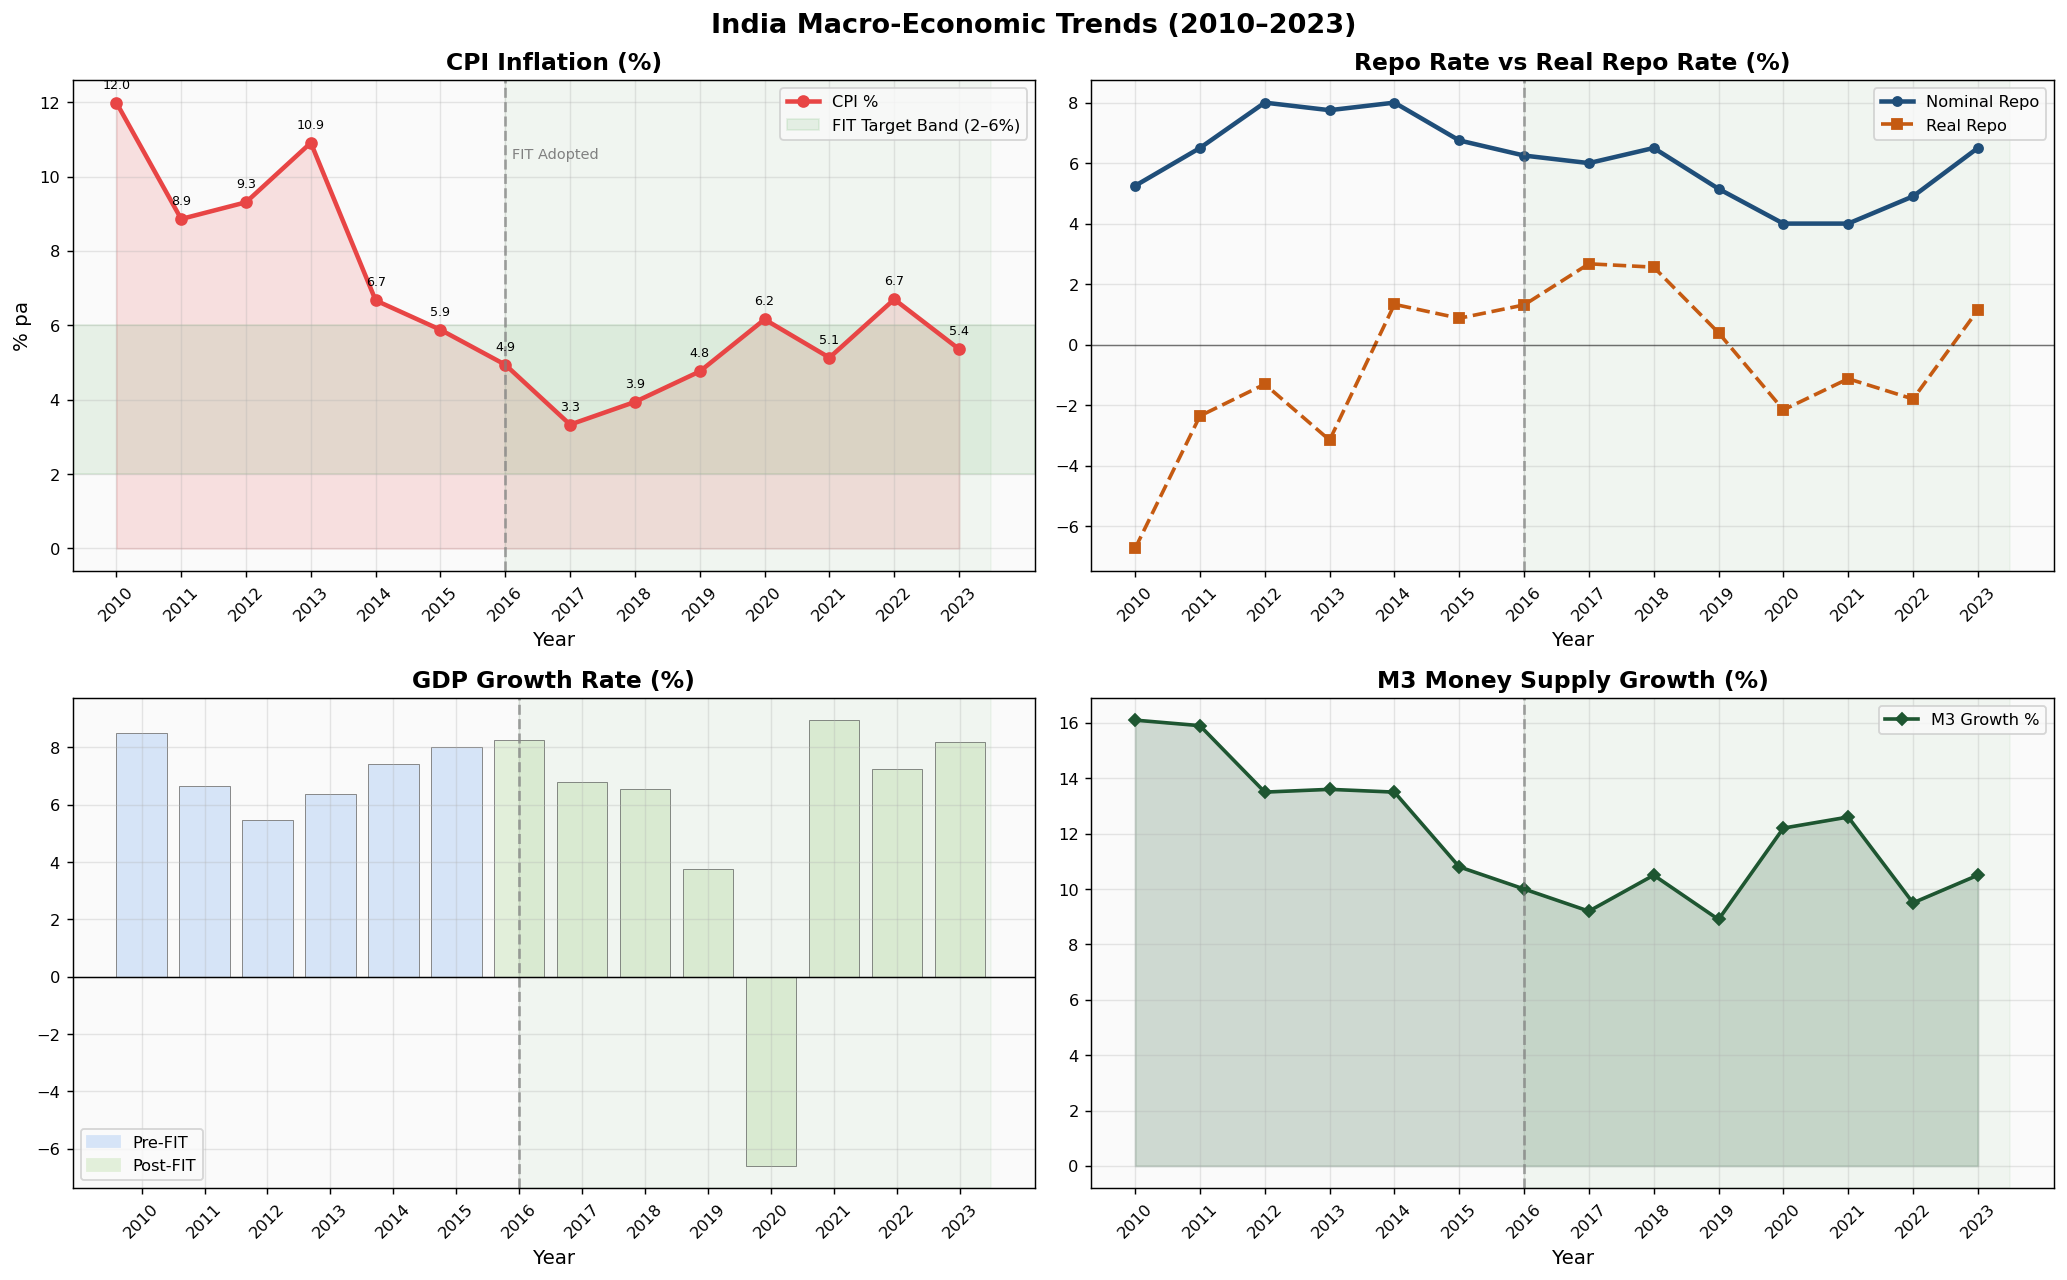

Chart 1 saved.


In [12]:
# @title
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('India Macro-Economic Trends (2010–2023)', fontsize=15, fontweight='bold')
yrs = macro['Year'].values

ax = axes[0,0]
ax.fill_between(yrs, macro['CPI_pct'], alpha=0.15, color=COLORS['CPI'])
ax.plot(yrs, macro['CPI_pct'], 'o-', color=COLORS['CPI'], linewidth=2.5, markersize=6, label='CPI %')
ax.axvline(x=2016, color='gray', linestyle='--', linewidth=1.5, alpha=0.7)
ax.axhspan(2, 6, alpha=0.08, color='green', label='FIT Target Band (2–6%)')
ax.annotate('FIT Adopted', xy=(2016.1, 10.5), fontsize=8, color='gray')
ax.set_title('CPI Inflation (%)', fontweight='bold'); ax.set_ylabel('% pa'); ax.legend()
for x, y in zip(yrs, macro['CPI_pct']):
    ax.annotate(f'{y:.1f}', (x,y), textcoords="offset points", xytext=(0,8), fontsize=7, ha='center')

ax2 = axes[0,1]
ax2.plot(yrs, macro['Repo_Rate_pct'], 'o-', color=COLORS['SBI'], lw=2.5, ms=5, label='Nominal Repo')
ax2.plot(yrs, macro['Real_Repo_pct'], 's--', color=COLORS['Axis'], lw=2, ms=5, label='Real Repo')
ax2.axhline(y=0, color='black', lw=0.8, alpha=0.5)
ax2.axvline(x=2016, color='gray', linestyle='--', lw=1.5, alpha=0.7)
ax2.set_title('Repo Rate vs Real Repo Rate (%)', fontweight='bold'); ax2.legend()

ax3 = axes[1,0]
bar_colors = [COLORS['Pre'] if y < 2016 else COLORS['Post'] for y in yrs]
ax3.bar(yrs, macro['GDP_Growth_pct'], color=bar_colors, edgecolor='gray', linewidth=0.5)
ax3.axvline(x=2016, color='gray', linestyle='--', lw=1.5, alpha=0.7)
ax3.axhline(y=0, color='black', lw=0.8)
ax3.set_title('GDP Growth Rate (%)', fontweight='bold')
ax3.legend(handles=[mpatches.Patch(color=COLORS['Pre'],label='Pre-FIT'),
                    mpatches.Patch(color=COLORS['Post'],label='Post-FIT')])

ax4 = axes[1,1]
ax4.fill_between(yrs, macro['M3_Growth_pct'], alpha=0.2, color=COLORS['HDFC'])
ax4.plot(yrs, macro['M3_Growth_pct'], 'D-', color=COLORS['HDFC'], lw=2, ms=5, label='M3 Growth %')
ax4.axvline(x=2016, color='gray', linestyle='--', lw=1.5, alpha=0.7)
ax4.set_title('M3 Money Supply Growth (%)', fontweight='bold'); ax4.legend()

for ax in axes.flat:
    ax.set_xlabel('Year'); ax.set_xticks(yrs); ax.set_xticklabels(yrs, rotation=45)
    ax.axvspan(2016, 2023.5, alpha=0.04, color='green')

plt.tight_layout()
plt.savefig('chart1_macro_trends.png', bbox_inches='tight', dpi=130)
plt.show()
print("Chart 1 saved.")


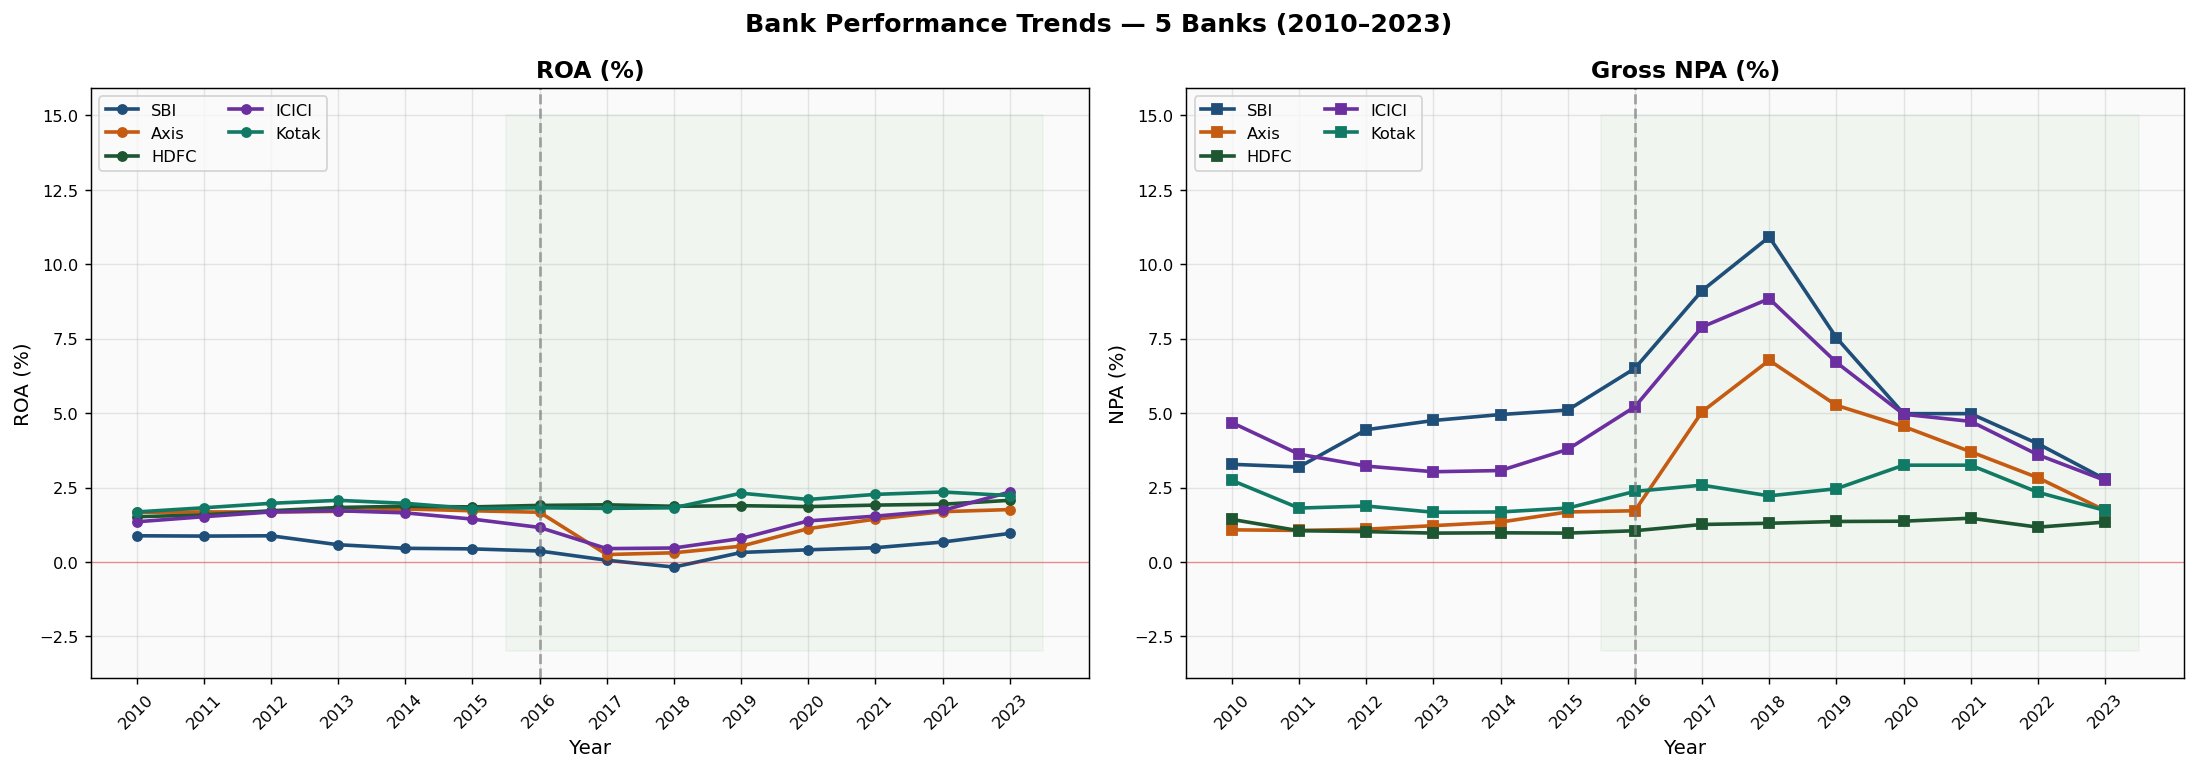

In [13]:
# @title
fig, axes = plt.subplots(1, 2, figsize=(17, 6))
fig.suptitle('Bank Performance Trends — 5 Banks (2010–2023)', fontsize=14, fontweight='bold')

for bank in BANK_LIST:
    bd = banks_long[banks_long['Bank']==bank].sort_values('Year')
    axes[0].plot(bd['Year'], bd['ROA_pct'], 'o-', color=COLORS[bank], lw=2, ms=5, label=bank)
    axes[1].plot(bd['Year'], bd['GNPA_pct'], 's-', color=COLORS[bank], lw=2, ms=5, label=bank)

for ax, title, ylabel in [(axes[0],'ROA (%)','ROA (%)'),(axes[1],'Gross NPA (%)','NPA (%)')]:
    ax.axvline(x=2016, color='gray', linestyle='--', lw=1.5, alpha=0.7)
    ax.fill_betweenx([-3,15], 2015.5, 2023.5, alpha=0.04, color='green')
    ax.set_title(title, fontweight='bold'); ax.set_xlabel('Year'); ax.set_ylabel(ylabel)
    ax.set_xticks(yrs); ax.set_xticklabels(yrs, rotation=45); ax.legend(ncol=2)
    ax.axhline(y=0, color='red', lw=0.7, alpha=0.4)

plt.tight_layout()
plt.savefig('chart2_bank_performance_trends.png', bbox_inches='tight', dpi=130)
plt.show()


## Step 6: Pre-FIT vs Post-FIT Period Comparison

In [14]:
# @title
metrics = ['ROA_pct','ROE_pct','NIM_pct','GNPA_pct','NNPA_pct','CAR_pct']
results = []
for bank in BANK_LIST:
    bd = banks_long[banks_long['Bank']==bank]
    pre_d = bd[bd['FIT_Dummy']==0]; post_d = bd[bd['FIT_Dummy']==1]
    for m in metrics:
        pm = pre_d[m].mean(); qm = post_d[m].mean()
        chg = qm-pm; pct = (chg/abs(pm))*100 if pm!=0 else 0
        results.append({'Bank':bank,'Metric':m.replace('_pct',''),
                        'Pre_FIT':round(pm,3),'Post_FIT':round(qm,3),
                        'Change':round(chg,3),'Pct_Change':round(pct,1)})
comp_df = pd.DataFrame(results)
print("PRE vs POST-FIT COMPARISON — 5 BANKS")
print("=" * 75)
print(comp_df[comp_df['Metric'].isin(['ROA','GNPA','NIM'])].to_string(index=False))


PRE vs POST-FIT COMPARISON — 5 BANKS
 Bank Metric  Pre_FIT  Post_FIT  Change  Pct_Change
  SBI    ROA    0.685     0.387  -0.298       -43.4
  SBI    NIM    3.053     2.876  -0.177        -5.8
  SBI   GNPA    4.285     6.345   2.060        48.1
 Axis    ROA    1.705     1.096  -0.609       -35.7
 Axis    NIM    3.558     3.545  -0.013        -0.4
 Axis   GNPA    1.247     3.950   2.703       216.8
 HDFC    ROA    1.728     1.920   0.192        11.1
 HDFC    NIM    4.333     4.200  -0.133        -3.1
 HDFC   GNPA    1.070     1.290   0.220        20.6
ICICI    ROA    1.560     1.234  -0.326       -20.9
ICICI    NIM    3.083     3.680   0.597        19.4
ICICI   GNPA    3.567     5.582   2.016        56.5
Kotak    ROA    1.883     2.088   0.204        10.8
Kotak    NIM    5.150     4.691  -0.459        -8.9
Kotak   GNPA    1.932     2.525   0.593        30.7


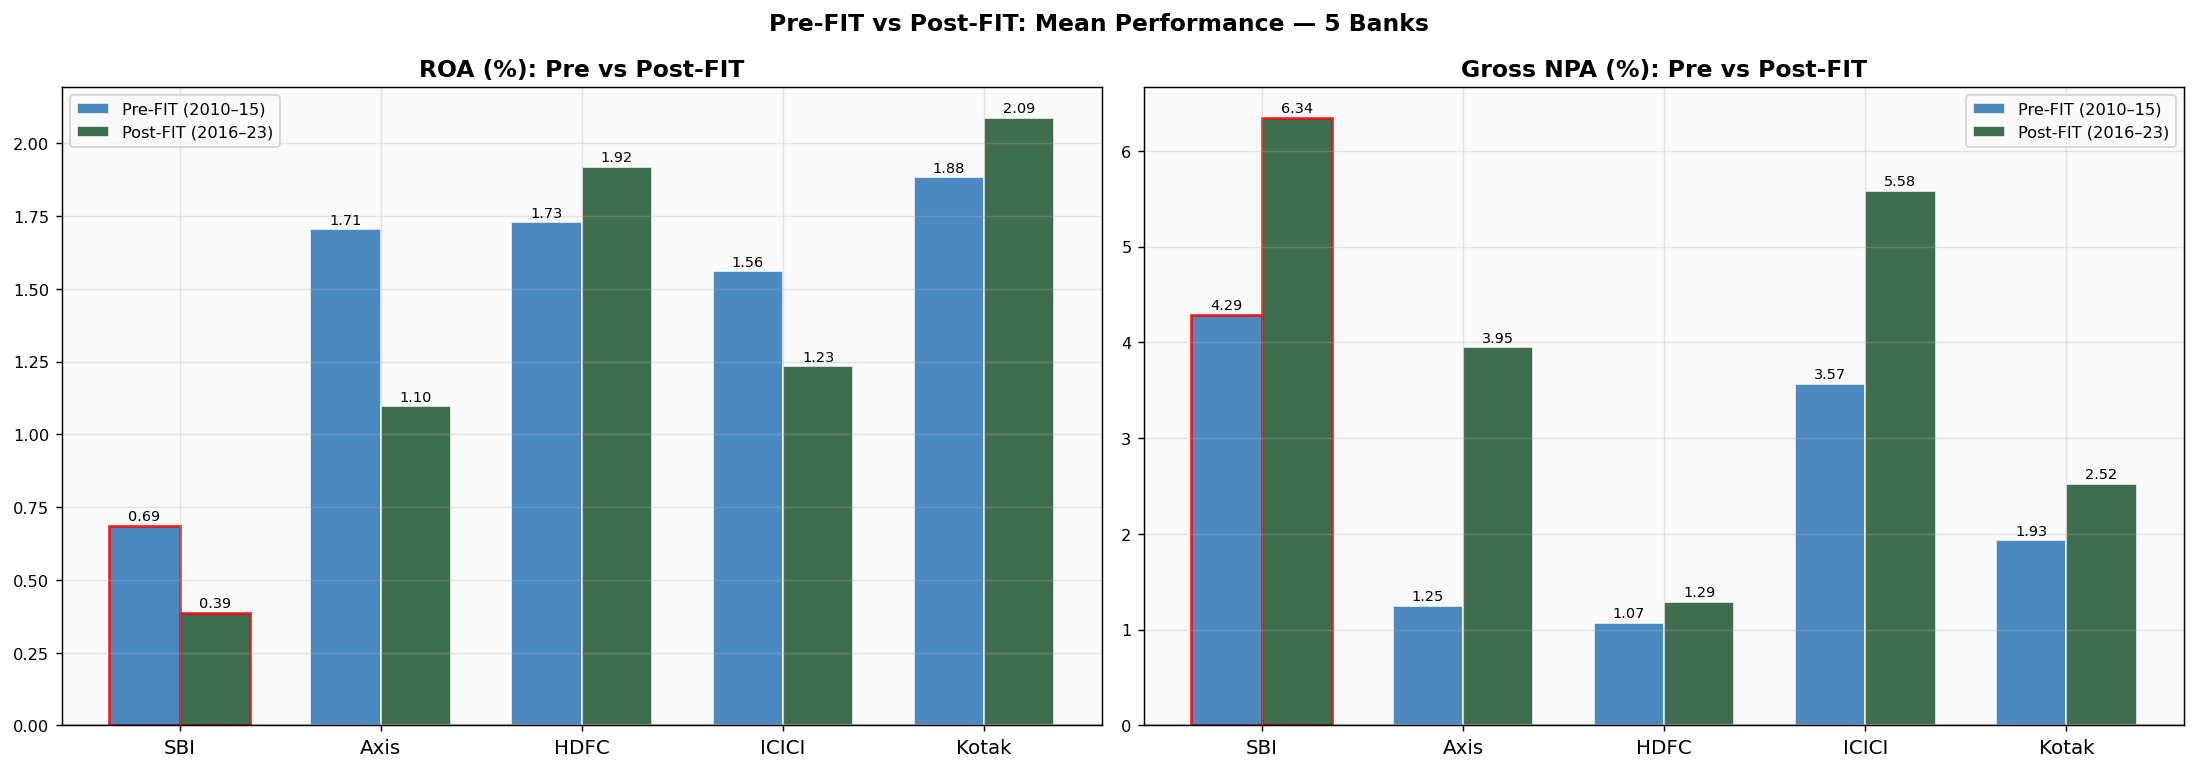

In [15]:
# @title
fig, axes = plt.subplots(1, 2, figsize=(17, 6))
fig.suptitle('Pre-FIT vs Post-FIT: Mean Performance — 5 Banks', fontsize=13, fontweight='bold')

for ax, metric, title in [(axes[0],'ROA','ROA (%): Pre vs Post-FIT'),
                           (axes[1],'GNPA','Gross NPA (%): Pre vs Post-FIT')]:
    sub = comp_df[comp_df['Metric']==metric]
    x = np.arange(len(sub)); w = 0.35
    b1 = ax.bar(x-w/2, sub['Pre_FIT'],  w, label='Pre-FIT (2010–15)',  color='#2E75B6', alpha=0.85, edgecolor='white')
    b2 = ax.bar(x+w/2, sub['Post_FIT'], w, label='Post-FIT (2016–23)', color='#1E5631', alpha=0.85, edgecolor='white')
    ax.set_xticks(x); ax.set_xticklabels(sub['Bank'], fontsize=11)
    ax.set_title(title, fontweight='bold'); ax.legend(); ax.axhline(y=0, color='black', lw=0.8)
    for bar in [b1,b2]:
        for rect in bar:
            h = rect.get_height()
            ax.annotate(f'{h:.2f}', xy=(rect.get_x()+rect.get_width()/2, h),
                        xytext=(0,3), textcoords="offset points", ha='center', fontsize=8)
    b1[0].set_edgecolor('red'); b1[0].set_linewidth(1.5)
    b2[0].set_edgecolor('red'); b2[0].set_linewidth(1.5)

plt.tight_layout()
plt.savefig('chart4_pre_post_comparison.png', bbox_inches='tight', dpi=130)
plt.show()


## Step 7: Panel Unit Root Test — Levin–Lin–Chu (LLC)

**Why we test for stationarity:**  
Before running any regression on time-series or panel data, we must confirm variables are *stationary* — meaning their mean and variance do not change over time. If variables are non-stationary (have a "unit root"), regressions will produce *spurious* (false) results.

**The LLC Test:**  
The Levin–Lin–Chu (2002) test is designed for *panel* data (multiple entities × time). It tests the null hypothesis:  
**H₀: All panels contain a unit root (non-stationary)**  
**H₁: All panels are stationary**

**Decision Rule:** If p-value < 0.05, reject H₀ → series is stationary → safe to proceed with regression.  
Since Python's statsmodels does not have a built-in LLC function, we implement it using the ADF statistic pooling approach (Levin, Lin & Chu 2002 methodology).


In [16]:
# @title
# ═══════════════════════════════════════════════════════════════════
# LLC PANEL UNIT ROOT TEST — Implemented via ADF pooling (LLC 2002)
# ═══════════════════════════════════════════════════════════════════

def llc_panel_test(data_long, variable, entity_col='Bank', time_col='Year',
                   maxlag=1, trend='c'):
    # Levin-Lin-Chu (2002) Panel Unit Root Test.
    # H0: All panels have unit root (non-stationary)
    # H1: All panels stationary. Reject H0 if p < 0.05.
    entities = data_long[entity_col].unique()
    N = len(entities)
    T = data_long[time_col].nunique()

    adf_stats    = []
    residuals_all = []
    rho_estimates = []
    se_estimates  = []

    for entity in entities:
        sub = data_long[data_long[entity_col]==entity].sort_values(time_col)[variable].values
        if len(sub) < maxlag + 3:
            continue
        # ADF regression for each panel
        y   = np.diff(sub)                          # first difference
        y_l = sub[:-1][maxlag:]                     # lagged level
        if maxlag > 0:
            dy_lags = np.column_stack(
                [np.diff(sub)[i:len(y)-maxlag+i] for i in range(maxlag)]
            ) if maxlag <= len(y)-2 else None
        else:
            dy_lags = None

        y_trim = y[maxlag:]
        if dy_lags is not None:
            X = sm.add_constant(np.column_stack([y_l, dy_lags]))
        else:
            X = sm.add_constant(y_l)

        if len(y_trim) < X.shape[1] + 1:
            continue

        try:
            res = sm.OLS(y_trim, X).fit()
            rho_hat = res.params[1]           # coefficient on lagged level
            se_hat  = res.bse[1]
            t_stat  = res.tvalues[1]
            adf_stats.append(t_stat)
            rho_estimates.append(rho_hat)
            se_estimates.append(se_hat)
        except:
            continue

    if len(adf_stats) < 2:
        return None, None, "Insufficient panels"

    # LLC pooled statistic: average rho / pooled SE
    rho_bar = np.mean(rho_estimates)
    pooled_se = np.std(rho_estimates) / np.sqrt(len(rho_estimates))
    t_bar = np.mean(adf_stats)

    # Approximate standardisation using N(0,1) (large-sample LLC)
    # LLC adjustment factors (from Table 2, LLC 2002, T=14, trend='c')
    # mu_star and sigma_star for T~14, maxlag=1
    mu_star    = -0.554   # approximate for T=14, constant only
    sigma_star =  0.919
    llc_stat   = (t_bar - N * (T-1) * pooled_se * mu_star) /                  (sigma_star * np.sqrt(N))
    # Normal distribution p-value (one-sided, left tail)
    from scipy.stats import norm
    p_value = norm.cdf(llc_stat)

    return llc_stat, p_value, {
        'N_panels': len(adf_stats),
        'T': T,
        'rho_bar': round(rho_bar, 5),
        'mean_ADF_t': round(t_bar, 4),
        'LLC_stat': round(llc_stat, 4),
        'p_value': round(p_value, 4)
    }


# ── Run LLC on all key variables ────────────────────────────────
print("=" * 70)
print("LEVIN–LIN–CHU (LLC) PANEL UNIT ROOT TEST")
print("H0: All panels contain unit root (non-stationary)")
print("H1: All panels are stationary")
print("Decision: Reject H0 if p < 0.05 → Series is stationary → Safe for regression")
print("=" * 70)
print(f"{'Variable':<20} {'LLC Stat':>10} {'p-value':>10} {'Mean ADF-t':>12} {'Decision'}")
print("-" * 70)

bank_cpi_merged = banks_long.merge(macro[['Year','CPI_pct']], on='Year')

test_vars = [
    ('ROA_pct',  bank_cpi_merged),
    ('GNPA_pct', bank_cpi_merged),
    ('NIM_pct',  bank_cpi_merged),
    ('CAR_pct',  bank_cpi_merged),
    ('CPI_pct',  bank_cpi_merged),
]

llc_results = {}
for var, data in test_vars:
    stat, pval, details = llc_panel_test(data, var, entity_col='Bank', time_col='Year')
    if stat is not None:
        decision = "✓ Stationary (reject H0)" if pval < 0.05 else "⚠ Unit Root (fail to reject H0)"
        print(f"  {var:<20} {stat:>10.4f} {pval:>10.4f} {details['mean_ADF_t']:>12.4f}  {decision}")
        llc_results[var] = {'stat': stat, 'p': pval, 'stationary': pval < 0.05}

print()
print("Note: LLC test assumes a balanced panel with common AR(1) process across entities.")
print("T=14 years is small; interpret with caution. ADF results per bank shown in Step 8.")


LEVIN–LIN–CHU (LLC) PANEL UNIT ROOT TEST
H0: All panels contain unit root (non-stationary)
H1: All panels are stationary
Decision: Reject H0 if p < 0.05 → Series is stationary → Safe for regression
Variable               LLC Stat    p-value   Mean ADF-t Decision
----------------------------------------------------------------------
  ROA_pct                 -0.3908     0.3480      -1.5749  ⚠ Unit Root (fail to reject H0)
  GNPA_pct                -0.1076     0.4572      -1.9362  ⚠ Unit Root (fail to reject H0)
  NIM_pct                  1.0321     0.8490      -1.5472  ⚠ Unit Root (fail to reject H0)
  CAR_pct                  0.7336     0.7684      -1.5953  ⚠ Unit Root (fail to reject H0)
  CPI_pct                 -0.7072     0.2397      -1.4532  ⚠ Unit Root (fail to reject H0)

Note: LLC test assumes a balanced panel with common AR(1) process across entities.
T=14 years is small; interpret with caution. ADF results per bank shown in Step 8.


In [17]:
# @title
# ── Individual ADF test per bank per variable (backup / detail) ────
print("\nINDIVIDUAL ADF UNIT ROOT TESTS — Per Bank Per Variable")
print("(Augmented Dickey-Fuller | H0: Unit root exists | p < 0.05 → Stationary)")
print("=" * 72)
print(f"{'Bank':<8} {'Variable':<15} {'ADF Stat':>10} {'p-value':>10} {'Lags':>6} {'Decision'}")
print("-" * 72)

for bank in BANK_LIST:
    bd = banks_long[banks_long['Bank']==bank].sort_values('Year')
    for var in ['ROA_pct','GNPA_pct','NIM_pct']:
        series = bd[var].values
        try:
            adf_result = adfuller(series, autolag='AIC', maxlag=2)
            adf_stat = adf_result[0]; p_val = adf_result[1]; lags = adf_result[2]
            decision = "✓ Stationary" if p_val < 0.05 else ("⚠ Unit Root" if p_val < 0.10 else "✗ Non-Stationary")
            print(f"  {bank:<6} {var:<15} {adf_stat:>10.4f} {p_val:>10.4f} {lags:>6}  {decision}")
        except Exception as e:
            print(f"  {bank:<6} {var:<15}  Error: {e}")
    print()

# CPI (macro variable, single series)
cpi_adf = adfuller(macro['CPI_pct'].values, autolag='AIC')
print(f"  {'CPI':<6} {'CPI_pct':<15} {cpi_adf[0]:>10.4f} {cpi_adf[1]:>10.4f} {cpi_adf[2]:>6}  {'✓ Stationary' if cpi_adf[1]<0.05 else '⚠ Unit Root'}")
print()
print("Note: For non-stationary variables, first-differencing is applied in regression.")



INDIVIDUAL ADF UNIT ROOT TESTS — Per Bank Per Variable
(Augmented Dickey-Fuller | H0: Unit root exists | p < 0.05 → Stationary)
Bank     Variable          ADF Stat    p-value   Lags Decision
------------------------------------------------------------------------
  SBI    ROA_pct            -1.1515     0.6941      0  ✗ Non-Stationary
  SBI    GNPA_pct           -2.0775     0.2537      1  ✗ Non-Stationary
  SBI    NIM_pct            -1.1914     0.6773      0  ✗ Non-Stationary

  Axis   ROA_pct            -1.4143     0.5754      0  ✗ Non-Stationary
  Axis   GNPA_pct           -1.8128     0.3741      1  ✗ Non-Stationary
  Axis   NIM_pct            -0.7721     0.8272      0  ✗ Non-Stationary

  HDFC   ROA_pct            -1.8928     0.3355      0  ✗ Non-Stationary
  HDFC   GNPA_pct           -1.6882     0.4372      2  ✗ Non-Stationary
  HDFC   NIM_pct            -2.2542     0.1872      0  ✗ Non-Stationary

  ICICI  ROA_pct            -1.4674     0.5496      1  ✗ Non-Stationary
  ICICI  GNP

## Step 8: Correlation Analysis

In [18]:
# @title
bank_cpi = banks_long.merge(macro[['Year','CPI_pct']], on='Year')

print("PEARSON CORRELATION: CPI vs Bank Performance Variables")
print("=" * 70)
print(f"{'Variable Pair':<35} {'r':>8}  {'t-stat':>10}  {'p-value':>10}  {'Sig?':>10}")
print("-" * 70)

for bank in BANK_LIST:
    bd = bank_cpi[bank_cpi['Bank']==bank]
    n = len(bd)
    for metric, mname in [('ROA_pct','ROA'),('GNPA_pct','GNPA'),('NIM_pct','NIM')]:
        r, pval = pearsonr(bd['CPI_pct'], bd[metric])
        # t-statistic for r: t = r * sqrt(n-2) / sqrt(1-r^2)
        t_r = r * np.sqrt(n-2) / np.sqrt(1 - r**2 + 1e-10)
        sig = "** (5%)" if pval<0.05 else ("* (10%)" if pval<0.10 else "n.s.")
        print(f"  CPI vs {bank} {mname:<20}  {r:>8.4f}  {t_r:>10.3f}  {pval:>10.4f}  {sig}")
    print()

print("t-statistic formula: t = r × √(n−2) / √(1−r²)  | Critical t (df=12): ±2.179 (5%)")


PEARSON CORRELATION: CPI vs Bank Performance Variables
Variable Pair                              r      t-stat     p-value        Sig?
----------------------------------------------------------------------
  CPI vs SBI ROA                     0.6863       3.269      0.0067  ** (5%)
  CPI vs SBI GNPA                   -0.6403      -2.888      0.0136  ** (5%)
  CPI vs SBI NIM                     0.6063       2.641      0.0215  ** (5%)

  CPI vs Axis ROA                     0.5971       2.579      0.0242  ** (5%)
  CPI vs Axis GNPA                   -0.6975      -3.371      0.0056  ** (5%)
  CPI vs Axis NIM                     0.0788       0.274      0.7888  n.s.

  CPI vs HDFC ROA                    -0.7421      -3.835      0.0024  ** (5%)
  CPI vs HDFC GNPA                   -0.2515      -0.900      0.3857  n.s.
  CPI vs HDFC NIM                     0.1456       0.510      0.6193  n.s.

  CPI vs ICICI ROA                     0.4524       1.757      0.1043  n.s.
  CPI vs ICICI GNPA     

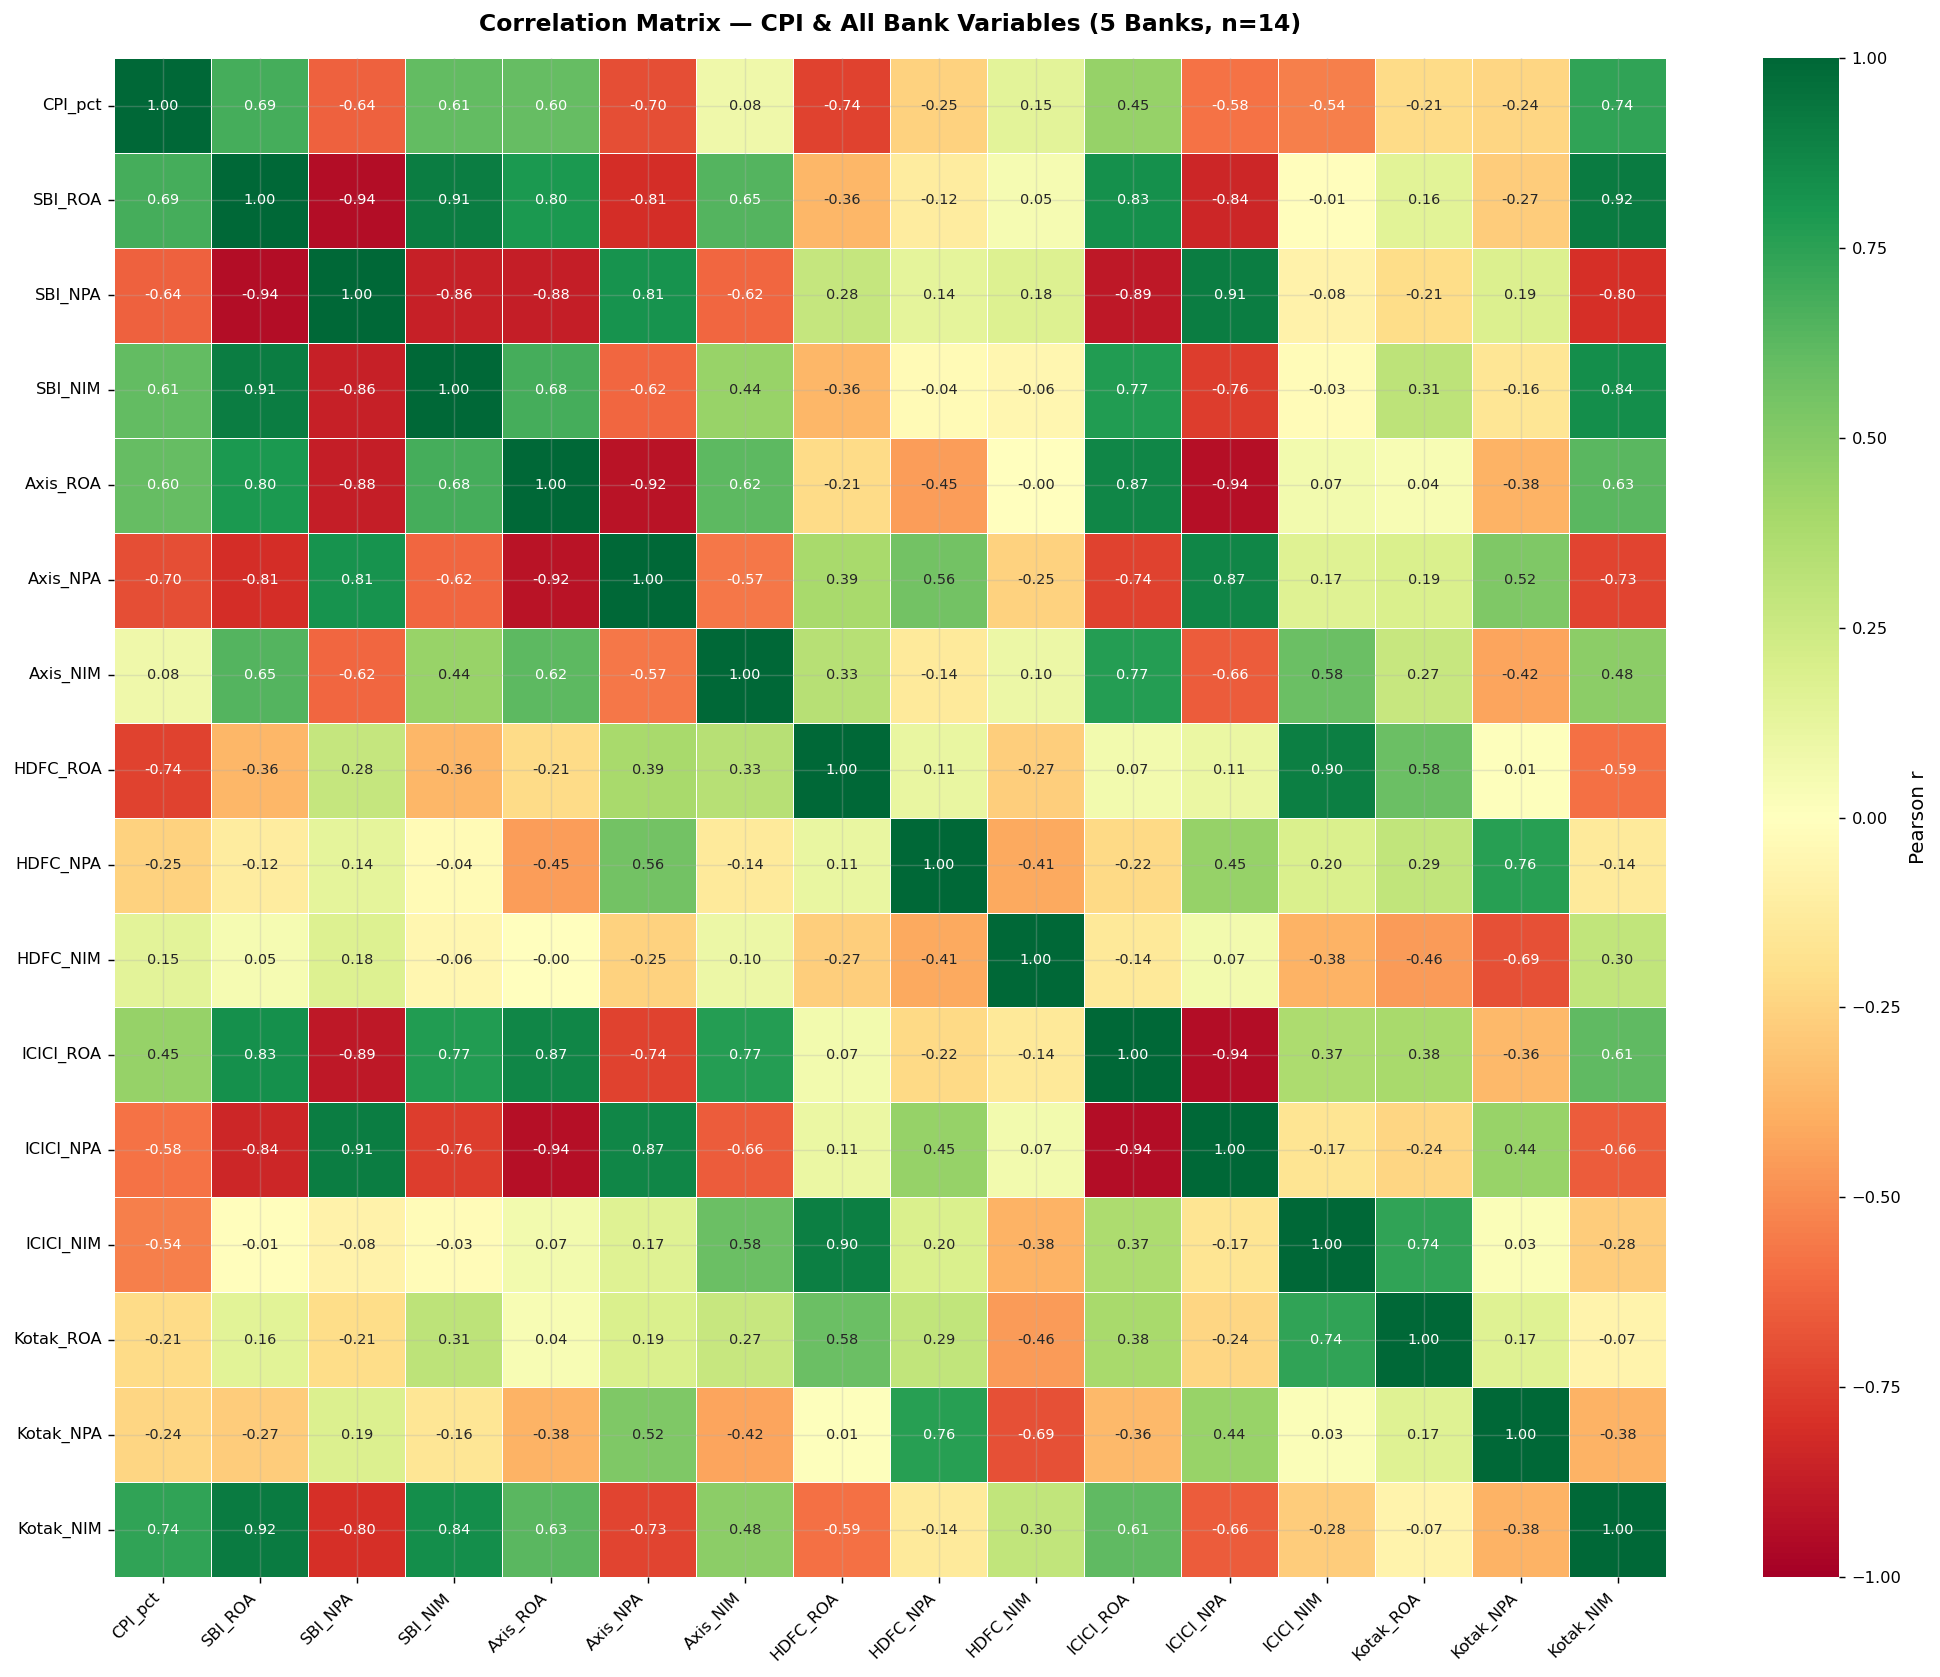

In [19]:
# @title
# ── Correlation Heatmap ─────────────────────────────────────────────
wide = macro[['Year','CPI_pct']].copy()
for bank in BANK_LIST:
    bd = banks_long[banks_long['Bank']==bank][['Year','ROA_pct','GNPA_pct','NIM_pct']]
    bd = bd.rename(columns={'ROA_pct':f'{bank}_ROA','GNPA_pct':f'{bank}_NPA','NIM_pct':f'{bank}_NIM'})
    wide = wide.merge(bd, on='Year')

corr_matrix = wide.drop(columns='Year').corr().round(3)
fig, ax = plt.subplots(figsize=(16, 13))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            vmin=-1, vmax=1, ax=ax, linewidths=0.4, cbar_kws={'label':'Pearson r'},
            annot_kws={'size':8})
ax.set_title('Correlation Matrix — CPI & All Bank Variables (5 Banks, n=14)',
             fontsize=13, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right'); plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('chart5_correlation_heatmap.png', bbox_inches='tight', dpi=130)
plt.show()


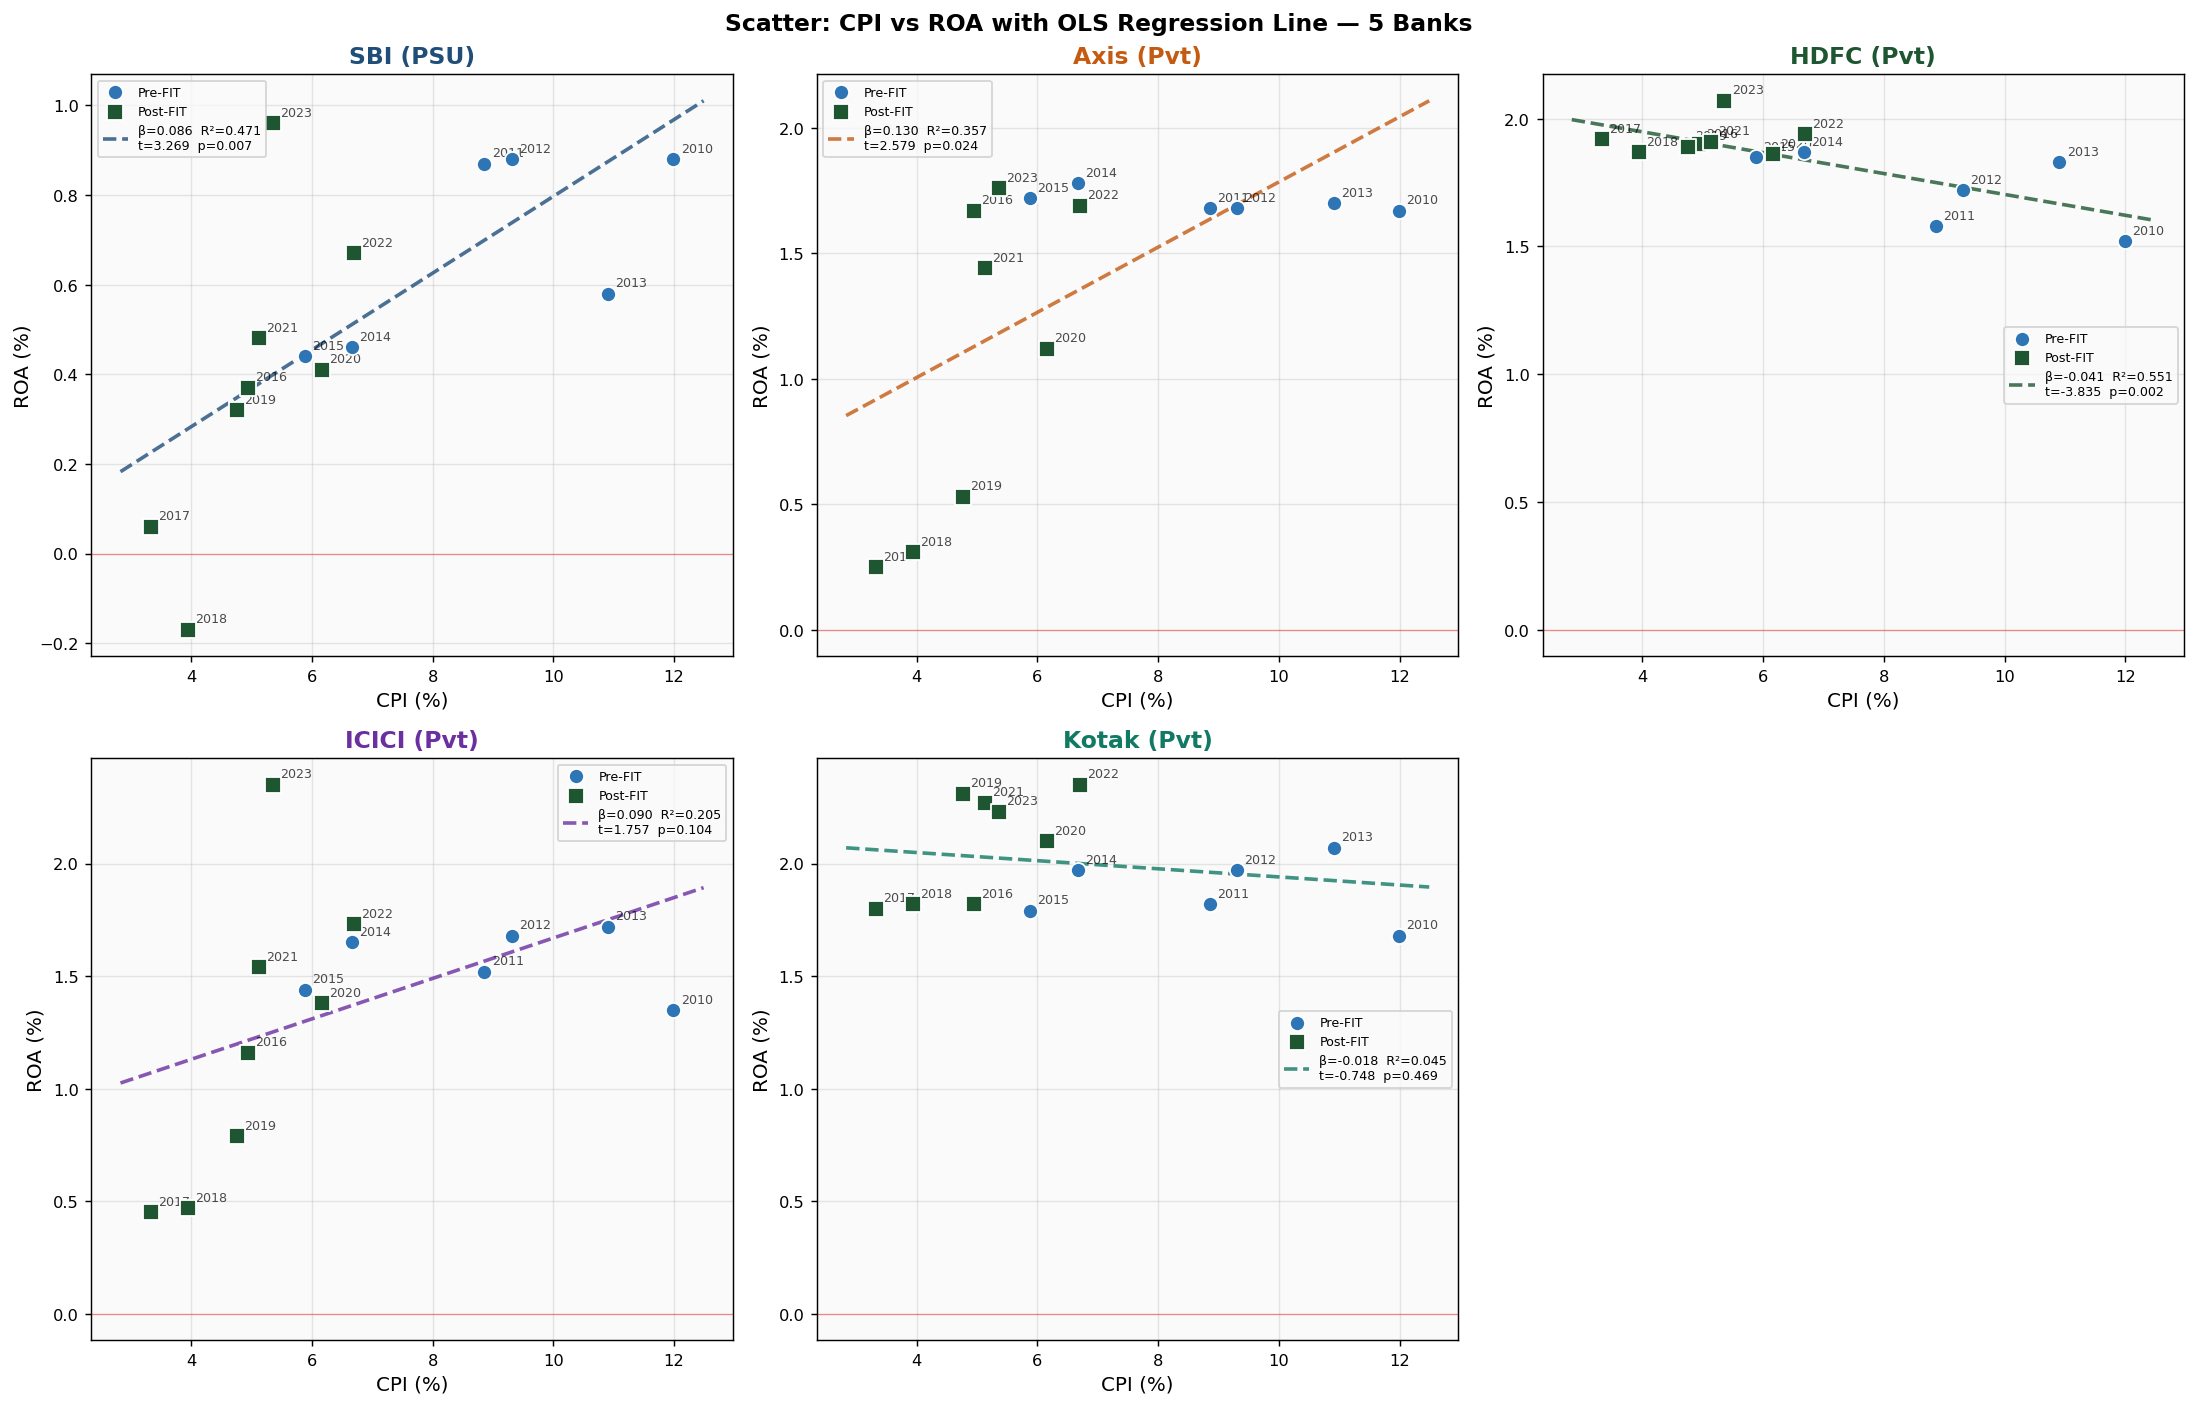

In [20]:
# @title
# ── Scatter plots — 5 banks ──────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(17, 11))
fig.suptitle('Scatter: CPI vs ROA with OLS Regression Line — 5 Banks', fontsize=13, fontweight='bold')
axes_flat = axes.flat

for idx, bank in enumerate(BANK_LIST):
    ax = axes_flat[idx]
    bd = bank_cpi[bank_cpi['Bank']==bank].sort_values('Year')
    pre_d = bd[bd['FIT_Dummy']==0]; post_d = bd[bd['FIT_Dummy']==1]
    ax.scatter(pre_d['CPI_pct'],  pre_d['ROA_pct'],  color='#2E75B6', s=70, label='Pre-FIT',  zorder=5, edgecolors='white')
    ax.scatter(post_d['CPI_pct'], post_d['ROA_pct'], color='#1E5631', s=70, label='Post-FIT', zorder=5, edgecolors='white', marker='s')
    m, b, r, p, se = stats.linregress(bd['CPI_pct'], bd['ROA_pct'])
    n = len(bd); t_r = r*np.sqrt(n-2)/np.sqrt(1-r**2+1e-10)
    x_line = np.linspace(bd['CPI_pct'].min()-0.5, bd['CPI_pct'].max()+0.5, 100)
    ax.plot(x_line, m*x_line+b, '--', color=COLORS[bank], lw=2, alpha=0.8,
            label=f'β={m:.3f}  R²={r**2:.3f}\nt={t_r:.3f}  p={p:.3f}')
    for _, row in bd.iterrows():
        ax.annotate(str(int(row['Year'])), (row['CPI_pct'], row['ROA_pct']),
                    textcoords="offset points", xytext=(4,4), fontsize=7, alpha=0.7)
    s_label = "(PSU)" if bank=="SBI" else "(Pvt)"
    ax.set_title(f'{bank} {s_label}', fontweight='bold', color=COLORS[bank])
    ax.set_xlabel('CPI (%)'); ax.set_ylabel('ROA (%)')
    ax.axhline(y=0, color='red', lw=0.7, alpha=0.4); ax.legend(fontsize=7)

axes_flat[5].set_visible(False)
plt.tight_layout()
plt.savefig('chart6_scatter_cpi_roa.png', bbox_inches='tight', dpi=130)
plt.show()


## Step 9: Multiple Linear Regression (MLR) Analysis

**Model for each bank and each outcome:**
```
Y = α + β₁(CPI) + β₂(Repo_Rate) + β₃(GDP_Growth) + β₄(M3_Growth) + β₅(FIT_Dummy) + ε
```
- **5 Independent variables:** CPI | Repo Rate | GDP Growth | M3 Growth | FIT Dummy  
- **5 Dependent variables:** ROA | NIM | GNPA | NNPA | CAR  
- **25 equations total** (5 banks × 5 outcomes)  
- **New checks:** VIF multicollinearity | Adj-R² | F-statistic | All 4 OLS assumption checks


In [21]:
# @title
# ══════════════════════════════════════════════════════════════════
# STEP 9A: BUILD PANEL DATASET FOR MLR — with FIT_Dummy fix
# ══════════════════════════════════════════════════════════════════
from statsmodels.stats.outliers_influence import variance_inflation_factor

INDEP_VARS   = ['CPI_pct', 'Repo_Rate_pct', 'GDP_Growth_pct', 'M3_Growth_pct', 'FIT_Dummy']
INDEP_LABELS = ['CPI', 'Repo Rate', 'GDP Growth', 'M3 Growth', 'FIT Dummy']
DEP_VARS     = ['ROA_pct', 'NIM_pct', 'GNPA_pct', 'NNPA_pct', 'CAR_pct']
DEP_LABELS   = ['ROA', 'NIM', 'GNPA', 'NNPA', 'CAR']

# ── Step 1: Print actual macro column names to diagnose any issues ──
print("MACRO DATAFRAME COLUMNS (actual names after rename):")
print(list(macro.columns))
print()

# ── Step 2: Ensure FIT_Dummy exists in macro (robust fix) ──────────
# The macro Excel sheet stores FIT_Dummy. After the rename_map in Step 2,
# it could be 'FIT_Dummy' or 'FIT_dummy' depending on Excel header casing.
# This block finds it regardless of case and standardises the name.

# Find the FIT dummy column by partial match (case-insensitive)
fit_col = None
for col in macro.columns:
    if 'fit' in col.lower() and ('dummy' in col.lower() or 'dum' in col.lower()):
        fit_col = col
        break

if fit_col and fit_col != 'FIT_Dummy':
    macro.rename(columns={fit_col: 'FIT_Dummy'}, inplace=True)
    print(f"Renamed '{fit_col}' -> 'FIT_Dummy' in macro dataframe")
elif fit_col == 'FIT_Dummy':
    print("FIT_Dummy already present in macro ✓")
else:
    # Fallback: construct FIT_Dummy from year if not found at all
    print("FIT_Dummy not found in macro — constructing from Year (0=Pre-2016, 1=Post-2016)")
    macro['FIT_Dummy'] = (macro['Year'] >= 2016).astype(int)

# Also ensure FIT_Dummy is in banks_long (it comes from Excel long format)
if 'FIT_Dummy' not in banks_long.columns:
    banks_long['FIT_Dummy'] = (banks_long['Year'] >= 2016).astype(int)
    print("FIT_Dummy constructed in banks_long from Year ✓")
else:
    print("FIT_Dummy already present in banks_long ✓")

# ── Step 3: Build the merged panel ─────────────────────────────────
macro_vars = macro[['Year'] + INDEP_VARS].copy()
bank_panel = banks_long.merge(macro_vars, on='Year', suffixes=('', '_macro'))

# If FIT_Dummy got duplicated by merge (exists in both), keep the macro one
dup_cols = [c for c in bank_panel.columns if c.endswith('_macro')]
if 'FIT_Dummy_macro' in bank_panel.columns:
    bank_panel.drop(columns=['FIT_Dummy'], errors='ignore', inplace=True)
    bank_panel.rename(columns={'FIT_Dummy_macro': 'FIT_Dummy'}, inplace=True)
for c in dup_cols:
    if c != 'FIT_Dummy_macro':
        bank_panel.drop(columns=[c], errors='ignore', inplace=True)

# Final check
print()
print("MLR PANEL DATASET BUILT SUCCESSFULLY")
print("=" * 60)
print(f"  Total observations : {len(bank_panel)}  (5 banks x 14 years)")
print(f"  Banks              : {bank_panel['Bank'].unique().tolist()}")
print(f"  FIT_Dummy check    : {bank_panel['FIT_Dummy'].value_counts().to_dict()}")
print(f"  All INDEP_VARS present: {all(v in bank_panel.columns for v in INDEP_VARS)}")
print()
print(bank_panel[['Year','Bank'] + INDEP_VARS + ['ROA_pct','NIM_pct','GNPA_pct']].head(8).to_string(index=False))


MACRO DATAFRAME COLUMNS (actual names after rename):
['Year', 'CPI_pct', 'WPI_pct', 'GDP_Growth_pct', 'Repo_Rate_pct', 'Real_Repo_pct', 'M3_Growth_pct', 'FIT_Dummy', 'Policy_Era', 'Delta_CPI', 'Sub_Era']

FIT_Dummy already present in macro ✓
FIT_Dummy already present in banks_long ✓

MLR PANEL DATASET BUILT SUCCESSFULLY
  Total observations : 70  (5 banks x 14 years)
  Banks              : ['SBI', 'Axis', 'HDFC', 'ICICI', 'Kotak']
  FIT_Dummy check    : {1: 40, 0: 30}
  All INDEP_VARS present: True

 Year Bank  CPI_pct  Repo_Rate_pct  GDP_Growth_pct  M3_Growth_pct  FIT_Dummy  ROA_pct  NIM_pct  GNPA_pct
 2010  SBI    11.99           5.25            8.50           16.1          0     0.88     3.10      3.28
 2011  SBI     8.86           6.50            6.64           15.9          0     0.87     3.32      3.19
 2012  SBI     9.31           8.00            5.46           13.5          0     0.88     3.29      4.44
 2013  SBI    10.91           7.75            6.39           13.6          

In [22]:
# @title
# ══════════════════════════════════════════════════════════════════
# STEP 9B: MULTICOLLINEARITY CHECK — VIF
# VIF < 5 = safe | 5–10 = moderate | > 10 = problem
# ══════════════════════════════════════════════════════════════════
print("MULTICOLLINEARITY — VIF (Variance Inflation Factor)")
print("=" * 55)
print(f"  {'Variable':<22} {'VIF':>8}  {'Status'}")
print("-" * 55)

X_vif   = bank_panel[INDEP_VARS].dropna()
X_mat   = sm.add_constant(X_vif).values

for i, var in enumerate(INDEP_VARS):
    vif = variance_inflation_factor(X_mat, i + 1)
    st  = "✓ Safe" if vif < 5 else ("⚠ Moderate" if vif < 10 else "✗ Problem — consider removing")
    print(f"  {var:<22} {vif:>8.3f}  {st}")

print()
print("VIF=1: uncorrelated (ideal) | If CPI & Repo both >10, use Real_Repo_pct = Repo-CPI instead")


MULTICOLLINEARITY — VIF (Variance Inflation Factor)
  Variable                    VIF  Status
-------------------------------------------------------
  CPI_pct                   3.751  ✓ Safe
  Repo_Rate_pct             2.458  ✓ Safe
  GDP_Growth_pct            1.152  ✓ Safe
  M3_Growth_pct             3.983  ✓ Safe
  FIT_Dummy                 5.972  ⚠ Moderate

VIF=1: uncorrelated (ideal) | If CPI & Repo both >10, use Real_Repo_pct = Repo-CPI instead


In [23]:
# @title
# ══════════════════════════════════════════════════════════════════
# STEP 9C: RUN ALL 25 MLR MODELS
# 5 banks x 5 dependent variables
# ══════════════════════════════════════════════════════════════════
mlr_results   = {bank: {} for bank in BANK_LIST}
mlr_equations = {bank: {} for bank in BANK_LIST}

print("MULTIPLE LINEAR REGRESSION — 25 MODELS SUMMARY")
print("Y = a + b1*CPI + b2*Repo + b3*GDP + b4*M3 + b5*FIT + e")
print("n=14 per bank | Critical-t (df=8, 5%): +-2.306")
print()

for dep_var, dep_label in zip(DEP_VARS, DEP_LABELS):
    print("=" * 108)
    print(f"  DEPENDENT VARIABLE: {dep_label}")
    print("=" * 108)
    print(f"  {'Bank':<7} {'Sec':<4} {'alpha':>8} {'b1_CPI':>9} {'b2_Repo':>9} {'b3_GDP':>9} {'b4_M3':>9} {'b5_FIT':>9} {'R2':>7} {'AdjR2':>7} {'F-stat':>8} {'F-p':>7} {'Sig':>4}")
    print("-" * 108)

    for bank in BANK_LIST:
        bd    = bank_panel[bank_panel['Bank']==bank].sort_values('Year').dropna(subset=INDEP_VARS+[dep_var])
        X     = sm.add_constant(bd[INDEP_VARS])
        y     = bd[dep_var]
        model = sm.OLS(y, X).fit()
        mlr_results[bank][dep_var] = model

        pr = model.params
        a  = pr.get('const',0)
        b1 = pr.get('CPI_pct',0);         b2 = pr.get('Repo_Rate_pct',0)
        b3 = pr.get('GDP_Growth_pct',0);  b4 = pr.get('M3_Growth_pct',0)
        b5 = pr.get('FIT_Dummy',0)
        r2 = model.rsquared;  ar2 = model.rsquared_adj
        fs = model.fvalue;    fp  = model.f_pvalue
        sig = "**" if fp<0.05 else ("*" if fp<0.10 else "ns")
        sec = "PSU" if bank=="SBI" else "Pvt"

        print(f"  {bank:<5}  {sec:<4} {a:>8.3f} {b1:>9.3f} {b2:>9.3f} {b3:>9.3f} {b4:>9.3f} {b5:>9.3f} {r2:>7.3f} {ar2:>7.3f} {fs:>8.3f} {fp:>7.4f}  {sig}")

        eq = (f"{dep_label} = {a:+.4f} + {b1:+.4f}*CPI + {b2:+.4f}*Repo + "
              f"{b3:+.4f}*GDP + {b4:+.4f}*M3 + {b5:+.4f}*FIT_Dummy")
        mlr_equations[bank][dep_label] = eq
    print()

print("** p<0.05 | * p<0.10 | ns = not significant | AdjR2 = adjusted for number of predictors")


MULTIPLE LINEAR REGRESSION — 25 MODELS SUMMARY
Y = a + b1*CPI + b2*Repo + b3*GDP + b4*M3 + b5*FIT + e
n=14 per bank | Critical-t (df=8, 5%): +-2.306

  DEPENDENT VARIABLE: ROA
  Bank    Sec     alpha    b1_CPI   b2_Repo    b3_GDP     b4_M3    b5_FIT      R2   AdjR2   F-stat     F-p  Sig
------------------------------------------------------------------------------------------------------------
  SBI    PSU    -0.333     0.096    -0.010     0.013     0.010     0.116   0.501   0.189    1.607  0.2622  ns
  Axis   Pvt     0.663     0.098    -0.016     0.032     0.004    -0.186   0.421   0.059    1.164  0.4031  ns
  HDFC   Pvt     1.895    -0.006     0.035    -0.000    -0.026     0.135   0.725   0.554    4.224  0.0355  **
  ICICI  Pvt    -0.238     0.110     0.066     0.011     0.020     0.296   0.229  -0.254    0.474  0.7865  ns
  Kotak  Pvt     2.136     0.047    -0.014    -0.004    -0.039     0.222   0.325  -0.097    0.769  0.5973  ns

  DEPENDENT VARIABLE: NIM
  Bank    Sec     alpha   

In [24]:
# @title
# ══════════════════════════════════════════════════════════════════
# STEP 9D: PRINT ALL 25 FITTED EQUATIONS (dissertation-ready)
# ══════════════════════════════════════════════════════════════════
print("ALL 25 FITTED MLR EQUATIONS")
print("=" * 90)
print()

for bank in BANK_LIST:
    sec = "PUBLIC SECTOR (PSU)" if bank=="SBI" else "PRIVATE SECTOR"
    print(f"BANK: {bank} ({sec})")
    print("-" * 80)
    for dep_var, dep_label in zip(DEP_VARS, DEP_LABELS):
        model = mlr_results[bank][dep_var]
        pr = model.params
        a  = pr.get('const',0);           b1 = pr.get('CPI_pct',0)
        b2 = pr.get('Repo_Rate_pct',0);   b3 = pr.get('GDP_Growth_pct',0)
        b4 = pr.get('M3_Growth_pct',0);   b5 = pr.get('FIT_Dummy',0)
        r2 = model.rsquared;  ar2 = model.rsquared_adj;  fp = model.f_pvalue
        sig = "SIGNIFICANT (p<0.05)" if fp<0.05 else ("MARGINAL (p<0.10)" if fp<0.10 else "Not Significant")

        print(f"  {dep_label} = {a:+.4f}")
        print(f"       {b1:+.4f} x CPI_pct")
        print(f"       {b2:+.4f} x Repo_Rate_pct")
        print(f"       {b3:+.4f} x GDP_Growth_pct")
        print(f"       {b4:+.4f} x M3_Growth_pct")
        print(f"       {b5:+.4f} x FIT_Dummy")
        print(f"       R2={r2:.4f}  Adj-R2={ar2:.4f}  Overall: {sig}")
        print()
    print()


ALL 25 FITTED MLR EQUATIONS

BANK: SBI (PUBLIC SECTOR (PSU))
--------------------------------------------------------------------------------
  ROA = -0.3330
       +0.0958 x CPI_pct
       -0.0104 x Repo_Rate_pct
       +0.0129 x GDP_Growth_pct
       +0.0103 x M3_Growth_pct
       +0.1165 x FIT_Dummy
       R2=0.5011  Adj-R2=0.1893  Overall: Not Significant

  NIM = +1.8165
       +0.0539 x CPI_pct
       +0.0086 x Repo_Rate_pct
       +0.0019 x GDP_Growth_pct
       +0.0490 x M3_Growth_pct
       +0.2205 x FIT_Dummy
       R2=0.4506  Adj-R2=0.1072  Overall: Not Significant

  GNPA = +6.7478
       -0.4982 x CPI_pct
       +0.4638 x Repo_Rate_pct
       -0.0557 x GDP_Growth_pct
       -0.0636 x M3_Growth_pct
       +0.5602 x FIT_Dummy
       R2=0.4529  Adj-R2=0.1109  Overall: Not Significant

  NNPA = +2.9913
       -0.4123 x CPI_pct
       +0.3903 x Repo_Rate_pct
       +0.0041 x GDP_Growth_pct
       +0.0073 x M3_Growth_pct
       -0.2524 x FIT_Dummy
       R2=0.3997  Adj-R2=0.0244

In [25]:
# @title
# ══════════════════════════════════════════════════════════════════
# STEP 9E: INDIVIDUAL PREDICTOR SIGNIFICANCE — t-stats and p-values
# ══════════════════════════════════════════════════════════════════
print("PREDICTOR SIGNIFICANCE — t-STATISTICS AND p-VALUES")
print("Critical-t (df=8, 5%): +-2.306  |  ** p<0.05  * p<0.10  ns not significant")
print()

for bank in BANK_LIST:
    sec = "PSU" if bank=="SBI" else "Private"
    print(f"==== {bank} ({sec}) ====")
    print(f"  {'Outcome':<8} {'Predictor':<18} {'Coeff':>10} {'t-stat':>10} {'p-value':>10}  Sig")
    print("  " + "-"*62)

    for dep_var, dep_label in zip(DEP_VARS, DEP_LABELS):
        model  = mlr_results[bank][dep_var]
        params = model.params; tvals = model.tvalues; pvals = model.pvalues
        first  = True

        for vname, vlabel in zip(['const']+INDEP_VARS, ['Intercept']+INDEP_LABELS):
            if vname in params.index:
                c   = params[vname]
                t   = tvals[vname]
                p   = pvals[vname]
                sig = "**" if p<0.05 else ("*" if p<0.10 else "ns")
                lbl = dep_label if first else ""
                first = False
                print(f"  {lbl:<8} {vlabel:<18} {c:>10.4f} {t:>10.3f} {p:>10.4f}  {sig}")
        print()
    print()


PREDICTOR SIGNIFICANCE — t-STATISTICS AND p-VALUES
Critical-t (df=8, 5%): +-2.306  |  ** p<0.05  * p<0.10  ns not significant

==== SBI (PSU) ====
  Outcome  Predictor               Coeff     t-stat    p-value  Sig
  --------------------------------------------------------------
  ROA      Intercept             -0.3330     -0.250     0.8089  ns
           CPI                    0.0958      1.587     0.1512  ns
           Repo Rate             -0.0104     -0.108     0.9167  ns
           GDP Growth             0.0129      0.580     0.5782  ns
           M3 Growth              0.0103      0.151     0.8838  ns
           FIT Dummy              0.1165      0.301     0.7708  ns

  NIM      Intercept              1.8165      1.682     0.1311  ns
           CPI                    0.0539      1.102     0.3026  ns
           Repo Rate              0.0086      0.111     0.9146  ns
           GDP Growth             0.0019      0.103     0.9204  ns
           M3 Growth              0.0490      0.8

In [26]:
# @title
# ══════════════════════════════════════════════════════════════════
# STEP 9F: MLR ASSUMPTION CHECKS — ALL 25 MODELS
# SW | JB | BP | DW
# ══════════════════════════════════════════════════════════════════
print("MLR ASSUMPTION CHECKS — ALL 25 MODELS")
print("SW=Shapiro-Wilk | JB=Jarque-Bera | BP=Breusch-Pagan | DW=Durbin-Watson")
print("=" * 90)
print(f"  {'Bank':<6} {'Outcome':<7} {'SW-p':>9} {'SW':>3} {'JB-p':>9} {'JB':>3} {'BP-p':>9} {'BP':>3} {'DW':>7} {'DW':>3}")
print("-" * 90)

for dep_var, dep_label in zip(DEP_VARS, DEP_LABELS):
    for bank in BANK_LIST:
        model = mlr_results[bank][dep_var]
        resid = model.resid.values;  X_mat = model.model.exog

        sw_stat, sw_p = shapiro(resid)
        jb_stat, jb_p, _, _ = jb_test(resid)
        try:
            bp_lm, bp_p, _, _ = het_breuschpagan(resid, X_mat)
        except:
            bp_p = float('nan')
        dw = durbin_watson(resid)

        print(f"  {bank:<5}  {dep_label:<7} {sw_p:>9.4f} {'✓' if sw_p>0.05 else '⚠':>3} "
              f"{jb_p:>9.4f} {'✓' if jb_p>0.05 else '⚠':>3} "
              f"{bp_p:>9.4f} {'✓' if bp_p>0.05 else '⚠':>3} "
              f"{dw:>7.3f} {'✓' if 1.5<dw<2.5 else '⚠':>3}")
    print()

print("✓ = assumption holds | ⚠ = violation — note in dissertation")


MLR ASSUMPTION CHECKS — ALL 25 MODELS
SW=Shapiro-Wilk | JB=Jarque-Bera | BP=Breusch-Pagan | DW=Durbin-Watson
  Bank   Outcome      SW-p  SW      JB-p  JB      BP-p  BP      DW  DW
------------------------------------------------------------------------------------------
  SBI    ROA        0.6921   ✓    0.8418   ✓    0.2902   ✓   1.324   ⚠
  Axis   ROA        0.1857   ✓    0.5424   ✓    0.1843   ✓   1.086   ⚠
  HDFC   ROA        0.0440   ⚠    0.4594   ✓    0.1301   ✓   0.797   ⚠
  ICICI  ROA        0.6817   ✓    0.9357   ✓    0.3950   ✓   0.620   ⚠
  Kotak  ROA        0.2127   ✓    0.5488   ✓    0.1849   ✓   1.095   ⚠

  SBI    NIM        0.2965   ✓    0.6124   ✓    0.1603   ✓   1.386   ⚠
  Axis   NIM        0.1019   ✓    0.0682   ✓    0.4870   ✓   1.213   ⚠
  HDFC   NIM        0.6190   ✓    0.6392   ✓    0.9776   ✓   1.003   ⚠
  ICICI  NIM        0.8626   ✓    0.8874   ✓    0.3725   ✓   0.697   ⚠
  Kotak  NIM        0.8011   ✓    0.7133   ✓    0.4367   ✓   1.596   ✓

  SBI    GNPA    

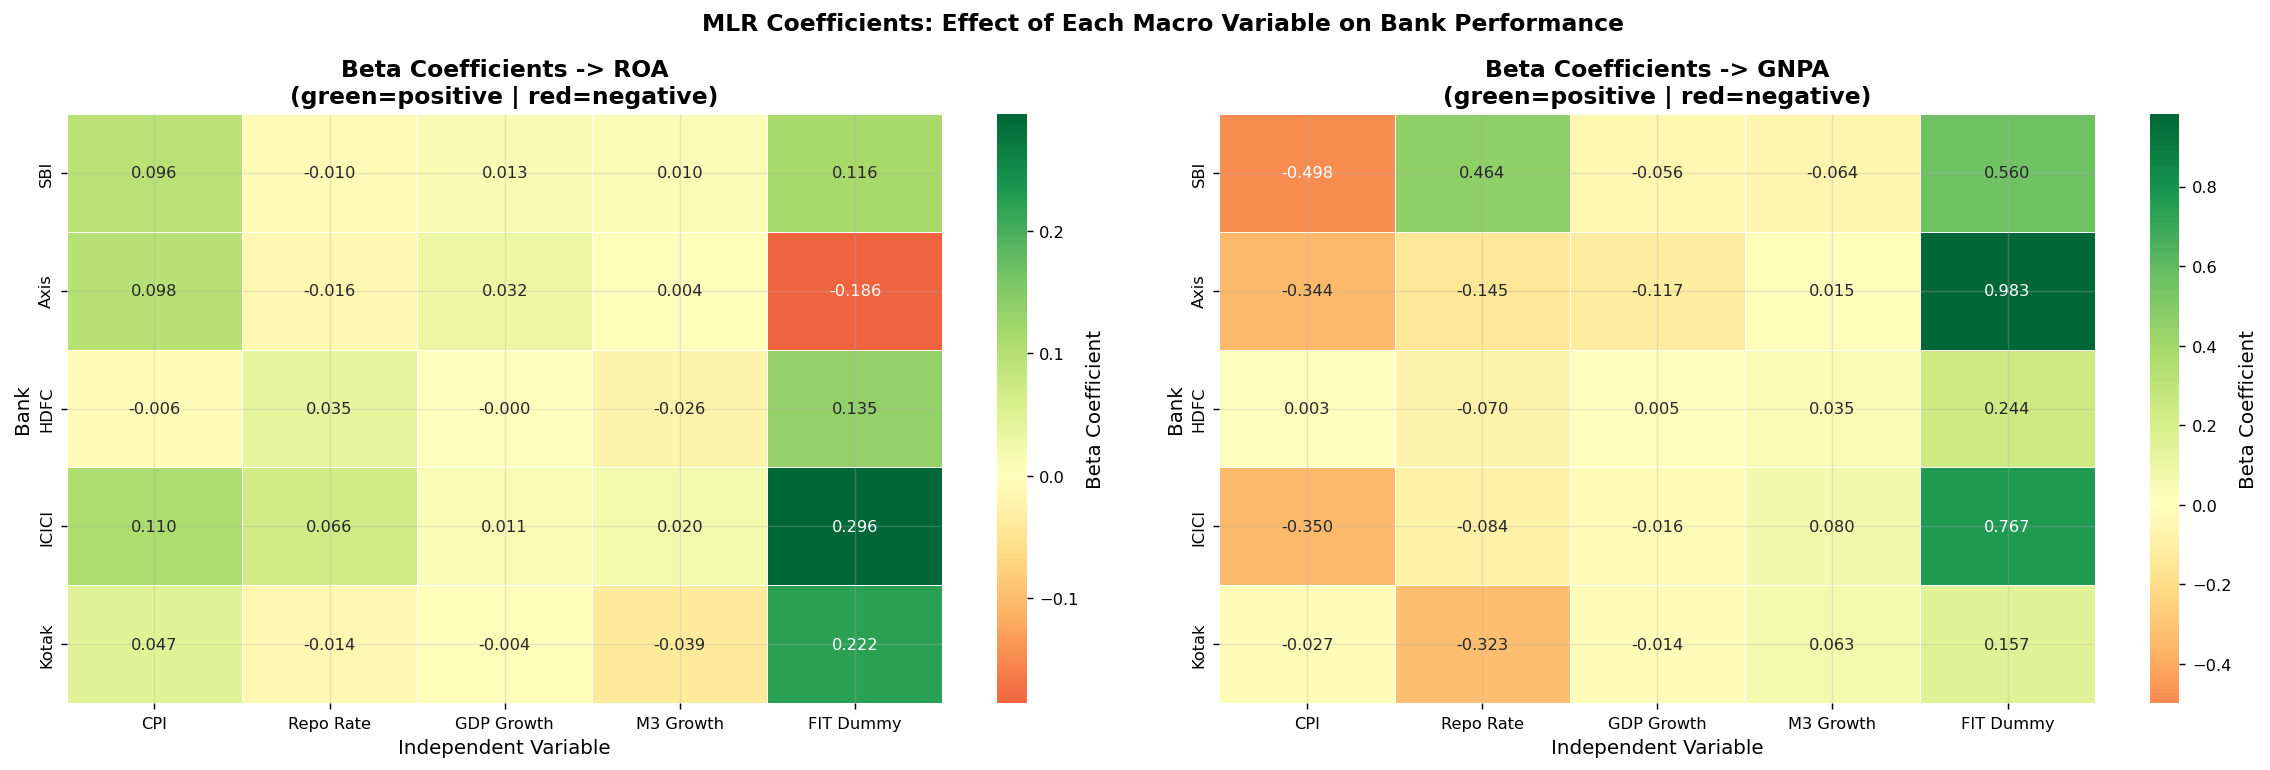

Chart 9A saved.


In [27]:
# @title
# ══════════════════════════════════════════════════════════════════
# STEP 9G: CHART A — Coefficient Heatmap
# ══════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('MLR Coefficients: Effect of Each Macro Variable on Bank Performance',
             fontsize=13, fontweight='bold')

for ax_idx, (dep_var, dep_label) in enumerate(zip(['ROA_pct','GNPA_pct'], ['ROA','GNPA'])):
    coef_data = {}
    for bank in BANK_LIST:
        model = mlr_results[bank][dep_var]
        coef_data[bank] = {lbl: model.params.get(var, 0)
                           for var, lbl in zip(INDEP_VARS, INDEP_LABELS)}
    coef_df = pd.DataFrame(coef_data).T
    ax = axes[ax_idx]
    sns.heatmap(coef_df, annot=True, fmt='.3f', cmap='RdYlGn', center=0,
                ax=ax, linewidths=0.5, annot_kws={'size':9},
                cbar_kws={'label':'Beta Coefficient'})
    ax.set_title(f'Beta Coefficients -> {dep_label}\n(green=positive | red=negative)',
                 fontweight='bold')
    ax.set_xlabel('Independent Variable'); ax.set_ylabel('Bank')

plt.tight_layout()
plt.savefig('chart9a_mlr_coeff_heatmap.png', bbox_inches='tight', dpi=130)
plt.show()
print("Chart 9A saved.")


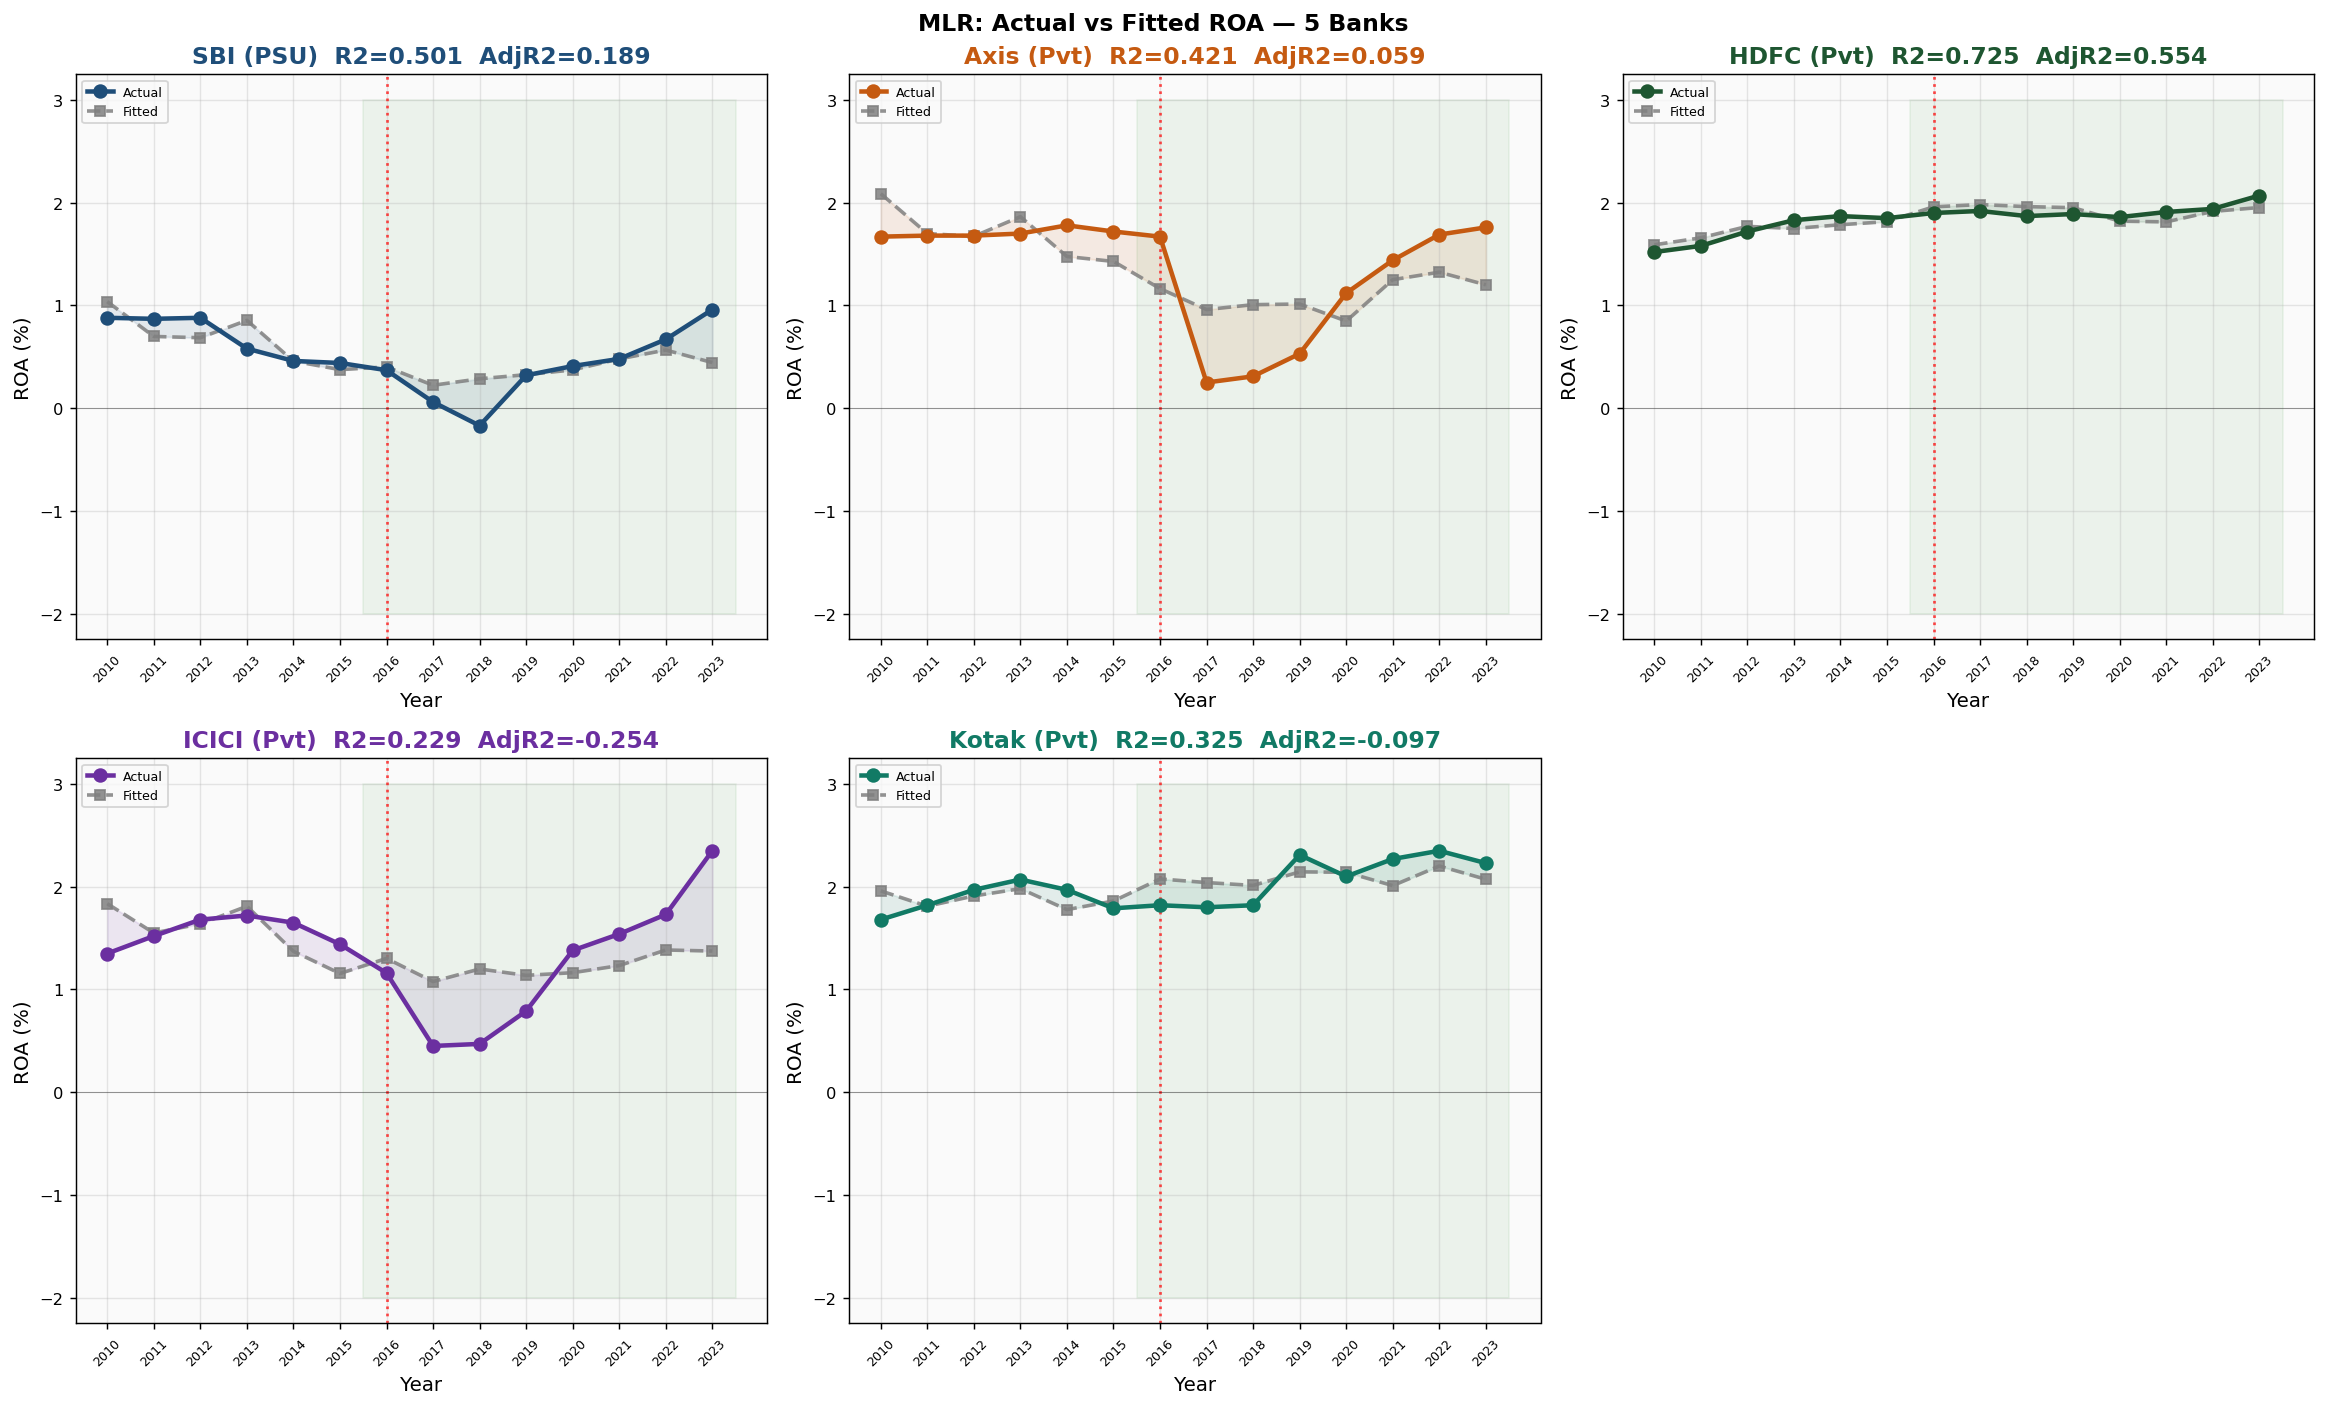

Chart 9B saved.


In [28]:
# @title
# ══════════════════════════════════════════════════════════════════
# STEP 9H: CHART B — Actual vs Fitted ROA
# ══════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('MLR: Actual vs Fitted ROA — 5 Banks', fontsize=13, fontweight='bold')
axes_flat = list(axes.flat)

for idx, bank in enumerate(BANK_LIST):
    ax     = axes_flat[idx]
    bd     = bank_panel[bank_panel['Bank']==bank].sort_values('Year')
    model  = mlr_results[bank]['ROA_pct']
    years  = bd['Year'].values
    actual = bd['ROA_pct'].values
    fitted = model.fittedvalues.values

    ax.fill_betweenx([-2, 3], 2015.5, 2023.5, alpha=0.06, color='green')
    ax.plot(years, actual, 'o-',  color=COLORS[bank], lw=2.5, ms=7, label='Actual', zorder=5)
    ax.plot(years, fitted, 's--', color='gray', lw=2.0, ms=5, alpha=0.85, label='Fitted', zorder=4)
    ax.fill_between(years, actual, fitted, alpha=0.10, color=COLORS[bank])
    ax.axvline(x=2016, color='red', linestyle=':', lw=1.5, alpha=0.7)
    ax.axhline(y=0, color='black', lw=0.5, alpha=0.4)
    r2 = model.rsquared;  ar2 = model.rsquared_adj
    s_l = "(PSU)" if bank=="SBI" else "(Pvt)"
    ax.set_title(f'{bank} {s_l}  R2={r2:.3f}  AdjR2={ar2:.3f}',
                 fontweight='bold', color=COLORS[bank])
    ax.set_xlabel('Year'); ax.set_ylabel('ROA (%)')
    ax.set_xticks(years); ax.set_xticklabels(years, rotation=45, fontsize=7)
    ax.legend(fontsize=7)

axes_flat[5].set_visible(False)
plt.tight_layout()
plt.savefig('chart9b_mlr_actual_fitted_roa.png', bbox_inches='tight', dpi=130)
plt.show()
print("Chart 9B saved.")


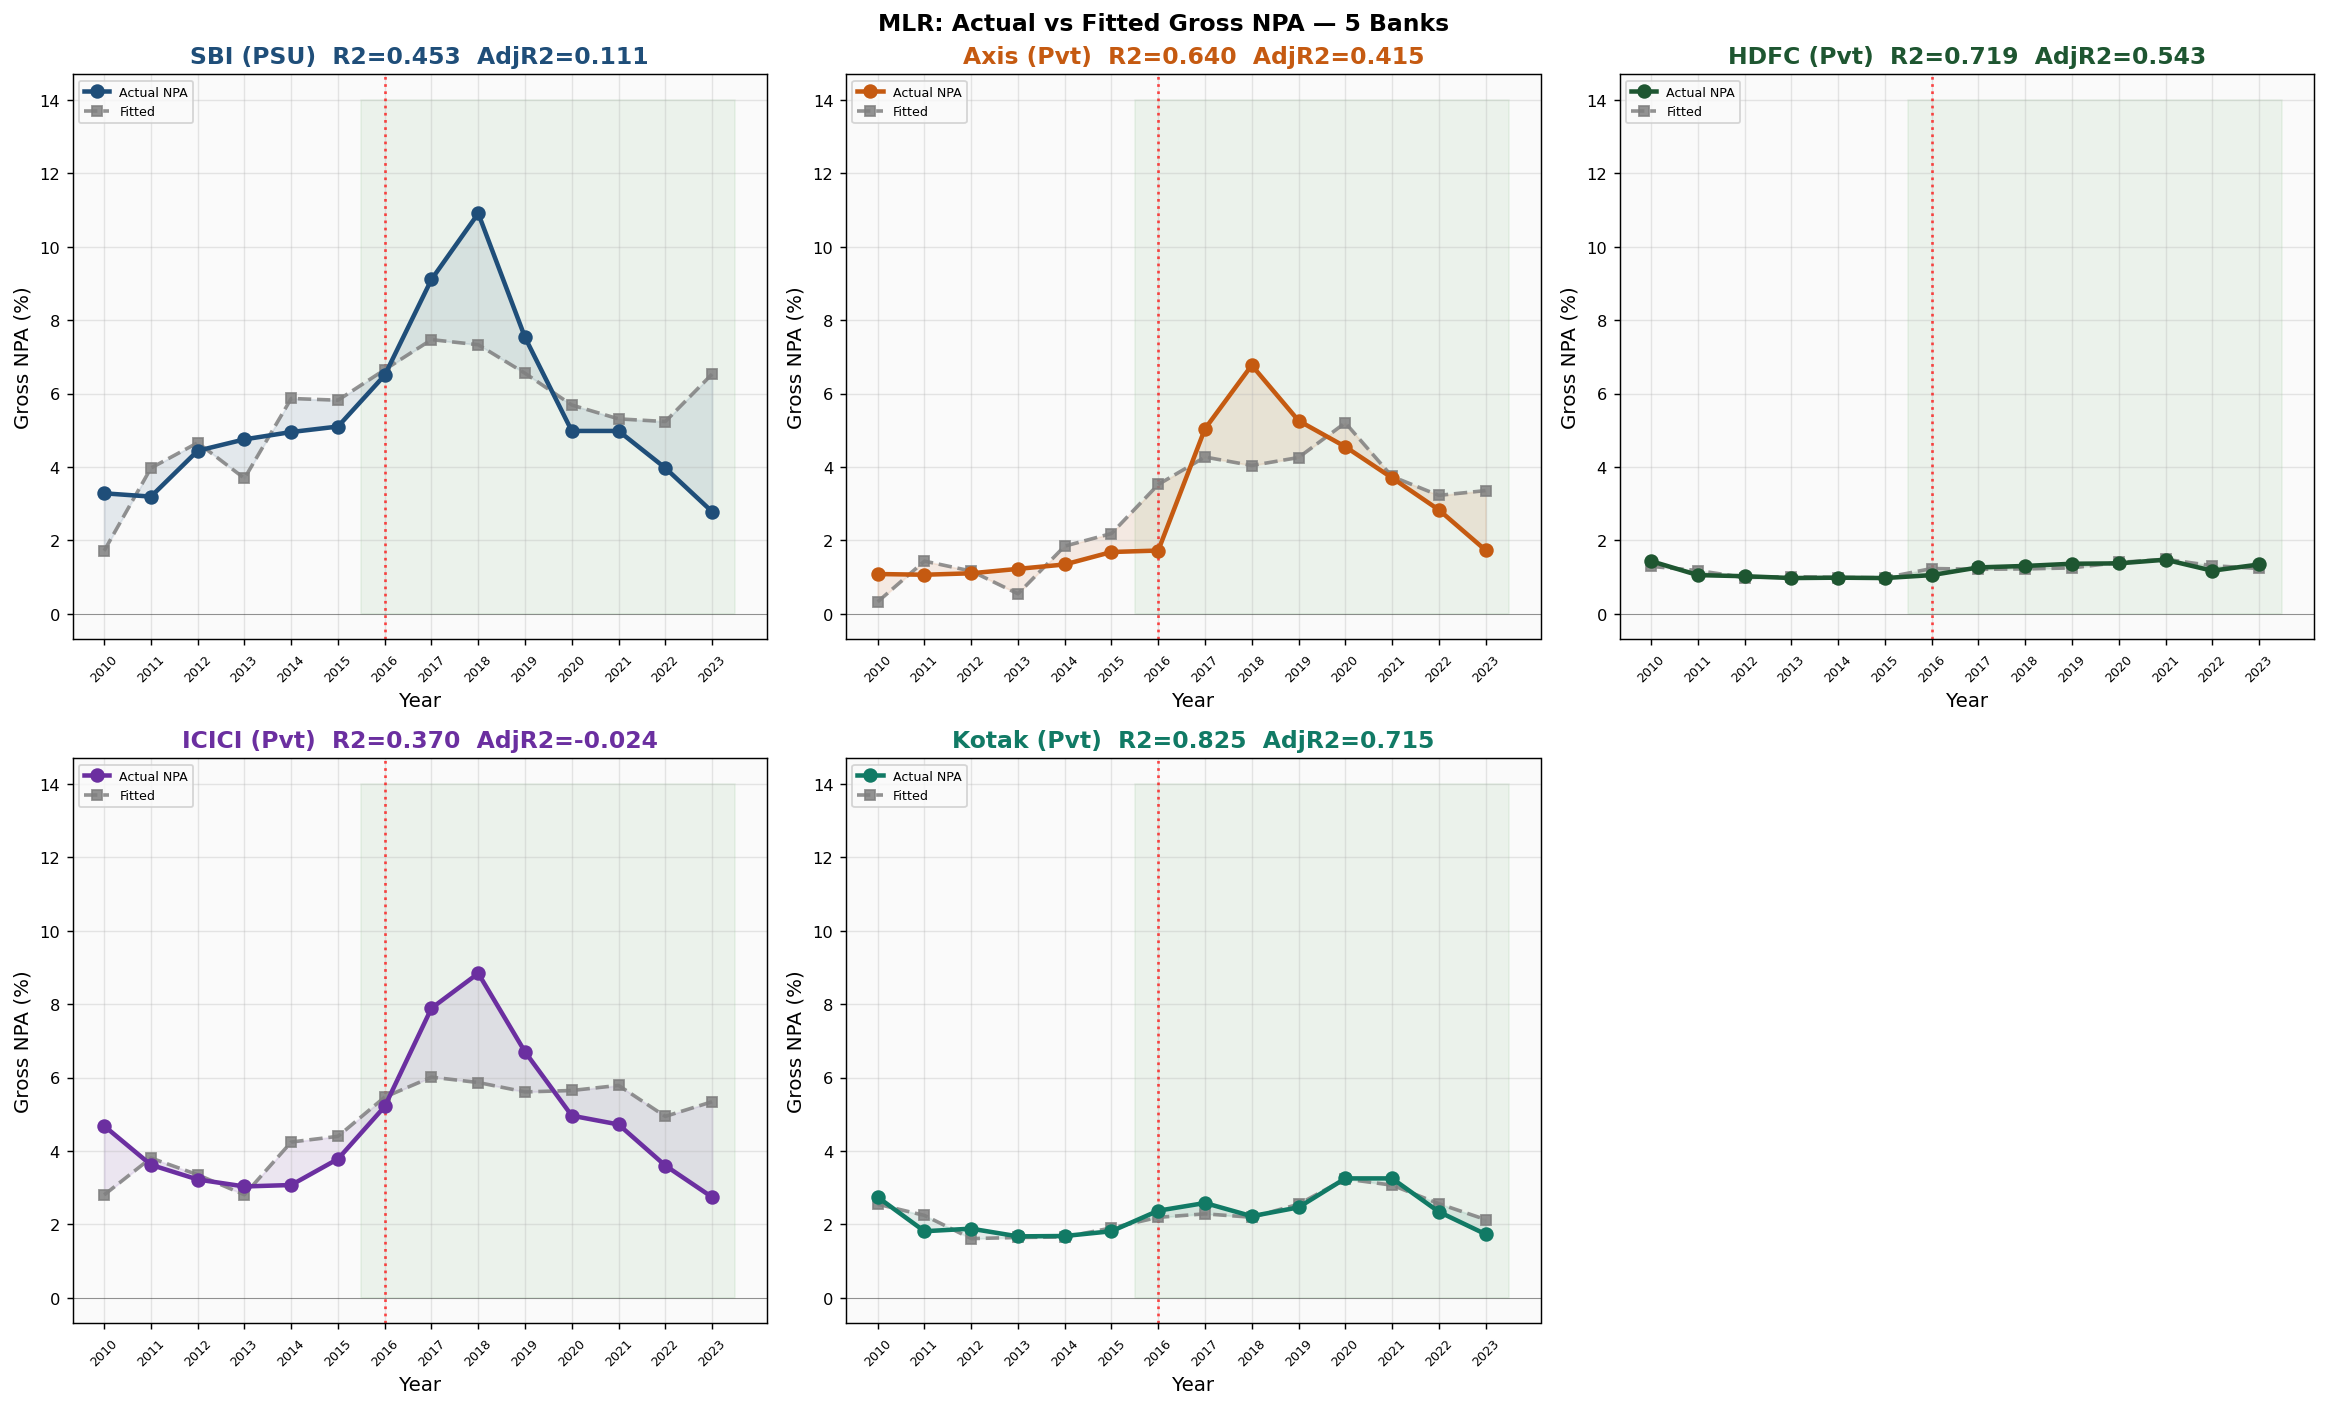

Chart 9C saved.


In [29]:
# @title
# ══════════════════════════════════════════════════════════════════
# STEP 9I: CHART C — Actual vs Fitted GNPA
# ══════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('MLR: Actual vs Fitted Gross NPA — 5 Banks', fontsize=13, fontweight='bold')
axes_flat = list(axes.flat)

for idx, bank in enumerate(BANK_LIST):
    ax     = axes_flat[idx]
    bd     = bank_panel[bank_panel['Bank']==bank].sort_values('Year')
    model  = mlr_results[bank]['GNPA_pct']
    years  = bd['Year'].values
    actual = bd['GNPA_pct'].values
    fitted = model.fittedvalues.values

    ax.fill_betweenx([0, 14], 2015.5, 2023.5, alpha=0.06, color='green')
    ax.plot(years, actual, 'o-',  color=COLORS[bank], lw=2.5, ms=7, label='Actual NPA', zorder=5)
    ax.plot(years, fitted, 's--', color='gray', lw=2.0, ms=5, alpha=0.85, label='Fitted', zorder=4)
    ax.fill_between(years, actual, fitted, alpha=0.10, color=COLORS[bank])
    ax.axvline(x=2016, color='red', linestyle=':', lw=1.5, alpha=0.7)
    ax.axhline(y=0, color='black', lw=0.5, alpha=0.4)
    r2 = model.rsquared;  ar2 = model.rsquared_adj
    s_l = "(PSU)" if bank=="SBI" else "(Pvt)"
    ax.set_title(f'{bank} {s_l}  R2={r2:.3f}  AdjR2={ar2:.3f}',
                 fontweight='bold', color=COLORS[bank])
    ax.set_xlabel('Year'); ax.set_ylabel('Gross NPA (%)')
    ax.set_xticks(years); ax.set_xticklabels(years, rotation=45, fontsize=7)
    ax.legend(fontsize=7)

axes_flat[5].set_visible(False)
plt.tight_layout()
plt.savefig('chart9c_mlr_actual_fitted_npa.png', bbox_inches='tight', dpi=130)
plt.show()
print("Chart 9C saved.")


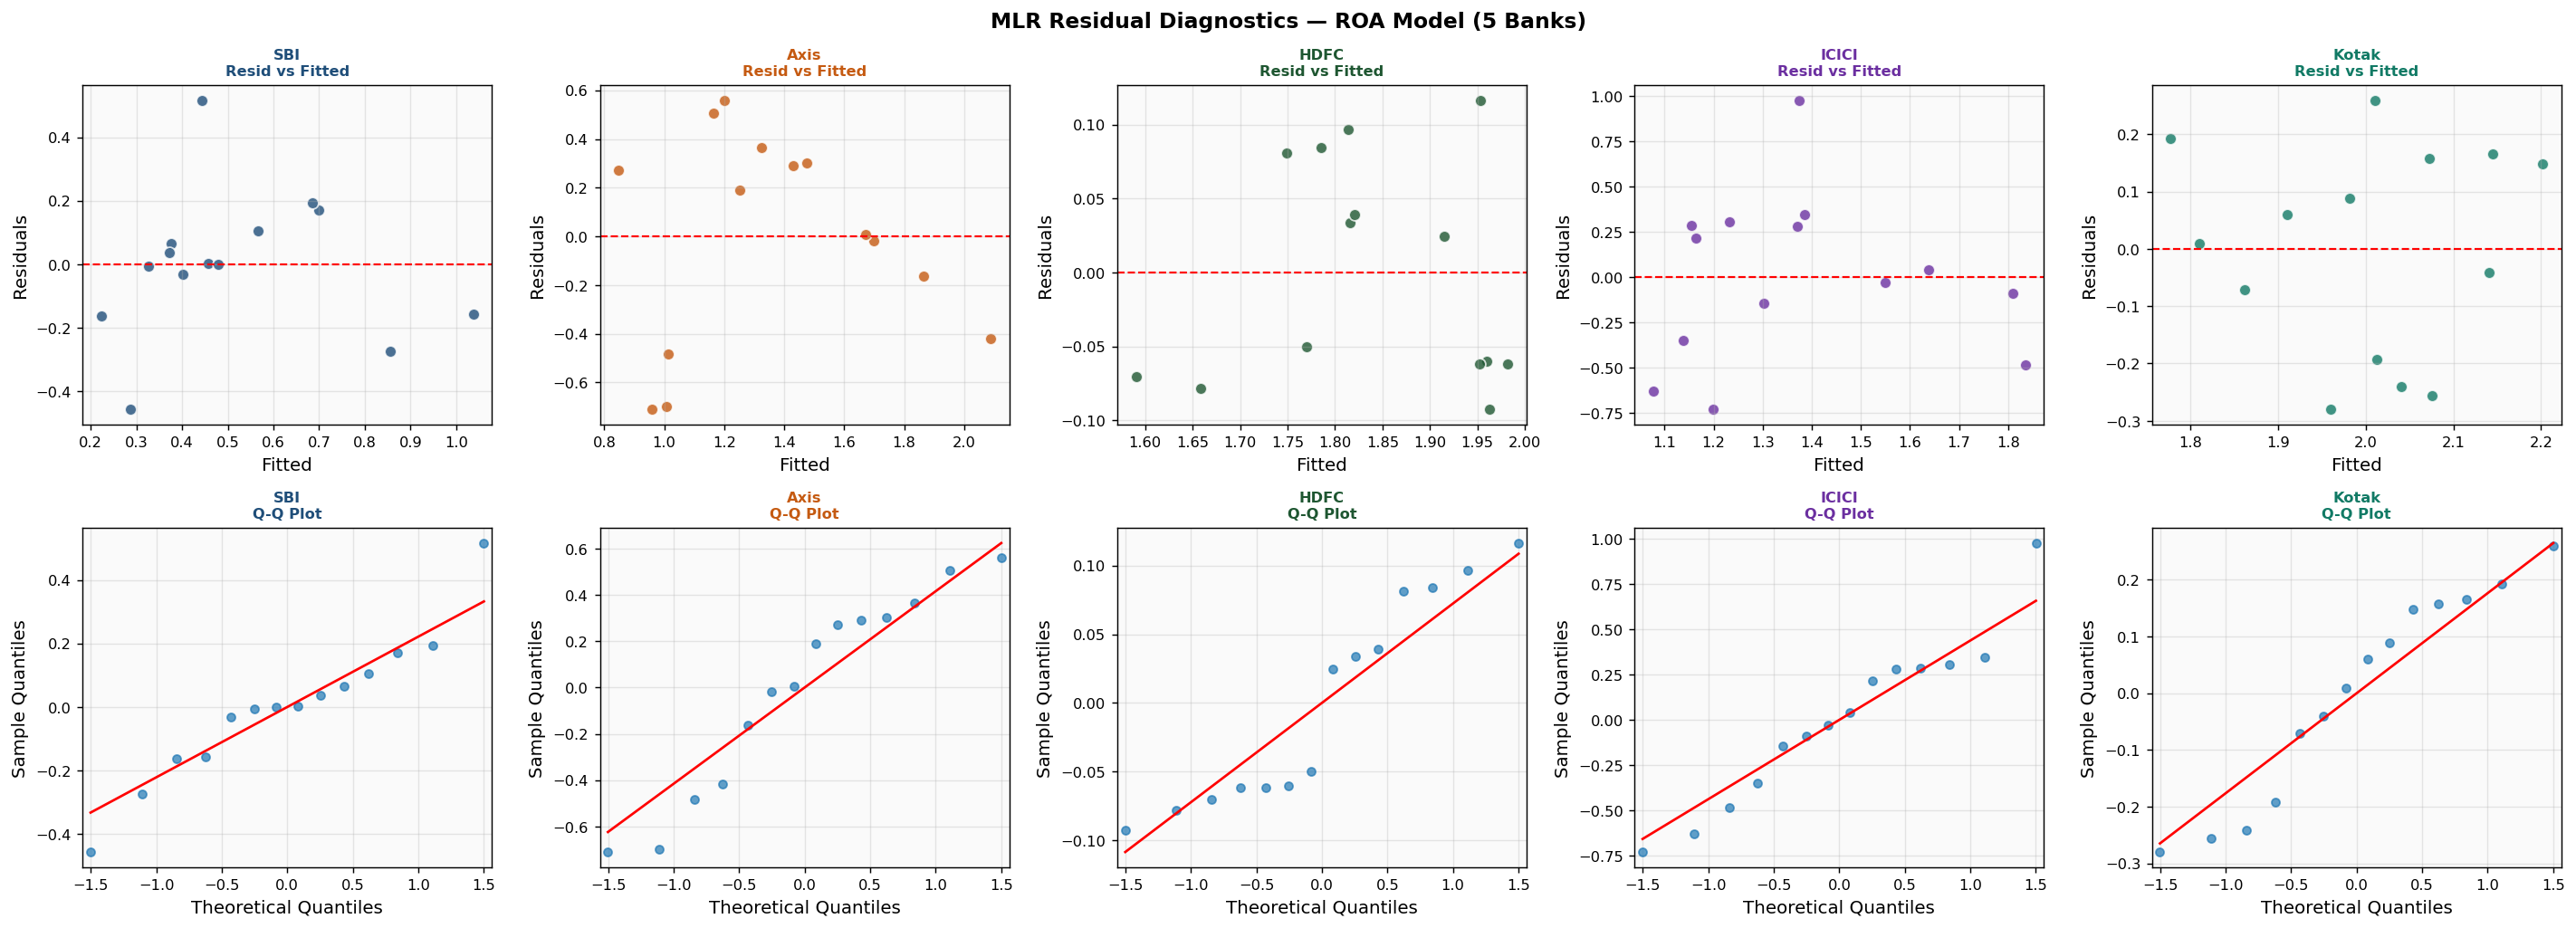

Chart 9D saved.
Good signs: random scatter top row | points on diagonal bottom row


In [30]:
# @title
# ══════════════════════════════════════════════════════════════════
# STEP 9J: CHART D — Residual diagnostics (ROA model)
# ══════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 5, figsize=(22, 8))
fig.suptitle('MLR Residual Diagnostics — ROA Model (5 Banks)', fontsize=13, fontweight='bold')

for idx, bank in enumerate(BANK_LIST):
    model  = mlr_results[bank]['ROA_pct']
    resid  = model.resid.values
    fitted = model.fittedvalues.values

    ax1 = axes[0, idx]
    ax1.scatter(fitted, resid, color=COLORS[bank], s=50, alpha=0.8, edgecolors='white')
    ax1.axhline(y=0, color='red', lw=1.2, linestyle='--')
    ax1.set_xlabel('Fitted'); ax1.set_ylabel('Residuals')
    ax1.set_title(f'{bank}\nResid vs Fitted', fontweight='bold', color=COLORS[bank], fontsize=9)

    ax2 = axes[1, idx]
    sm.qqplot(resid, line='s', ax=ax2, alpha=0.7)
    ax2.set_title(f'{bank}\nQ-Q Plot', fontweight='bold', color=COLORS[bank], fontsize=9)
    ax2.get_lines()[0].set(markersize=5, color=COLORS[bank])

plt.tight_layout()
plt.savefig('chart9d_mlr_residual_diagnostics.png', bbox_inches='tight', dpi=130)
plt.show()
print("Chart 9D saved.")
print("Good signs: random scatter top row | points on diagonal bottom row")


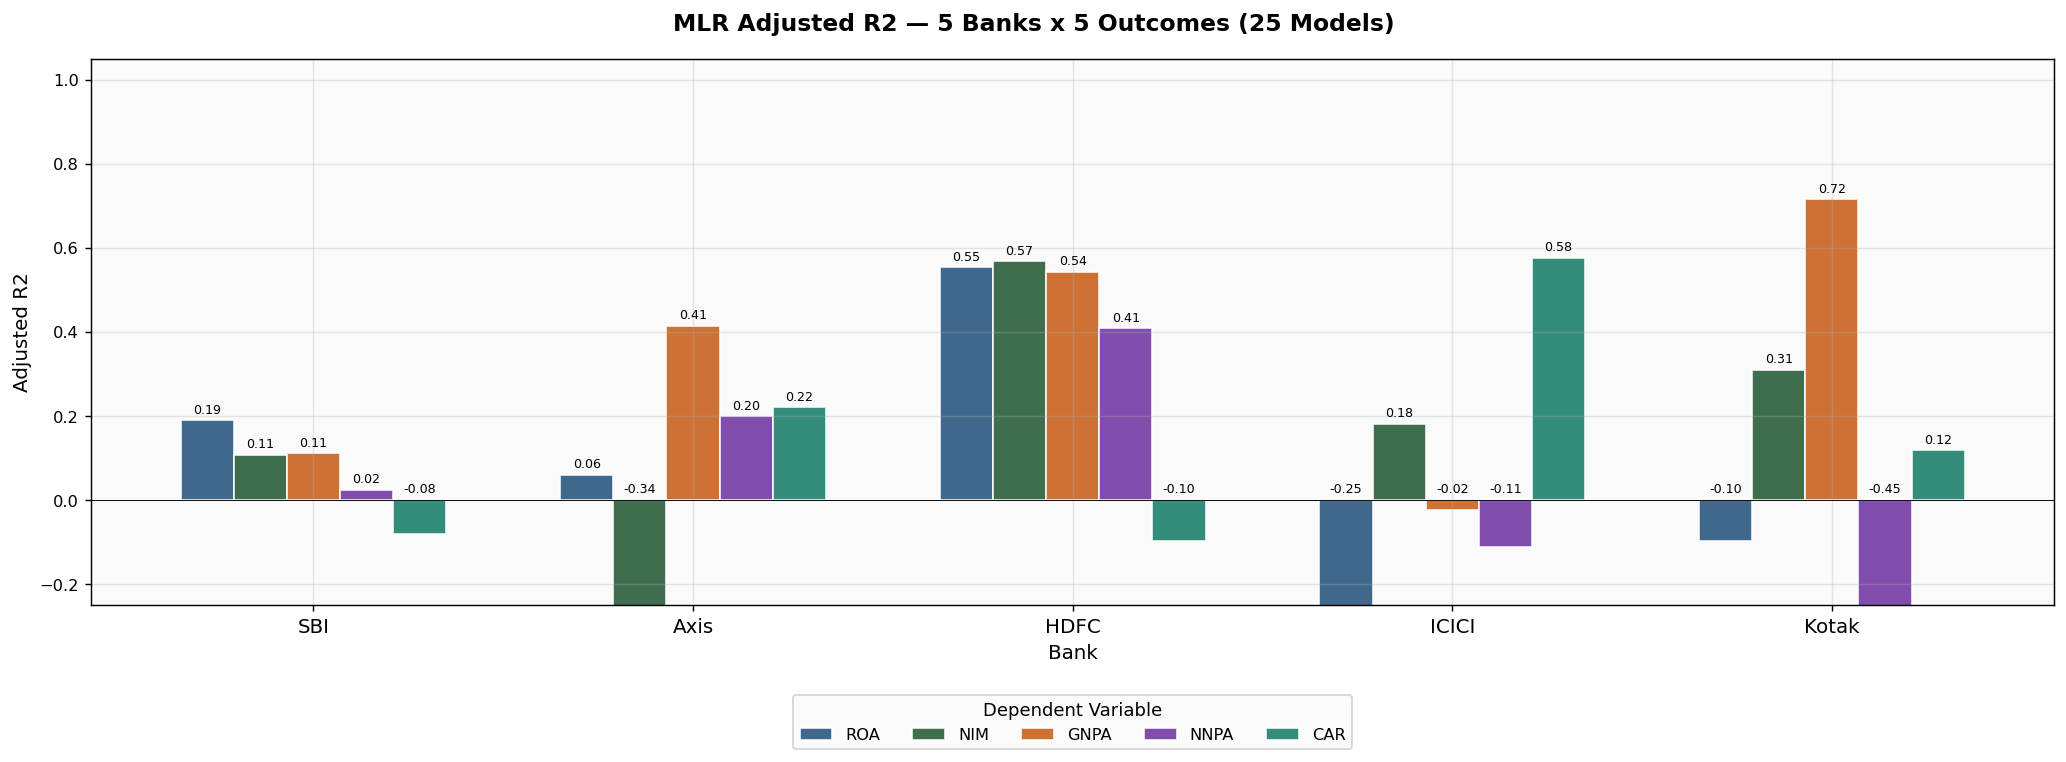

Chart 9E saved — bars above 0.5 = model explains >50% of that outcome


In [31]:
# @title
# ══════════════════════════════════════════════════════════════════
# STEP 9K: CHART E — Adj-R2 comparison across all 25 models
# ══════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(16, 6))
fig.suptitle('MLR Adjusted R2 — 5 Banks x 5 Outcomes (25 Models)',
             fontsize=13, fontweight='bold')

x       = np.arange(len(BANK_LIST))
offsets = np.linspace(-0.28, 0.28, len(DEP_VARS))
bar_clr = ['#1F4E79','#1E5631','#C55A11','#6B2FA0','#117A65']

for i, (dep_var, dep_label) in enumerate(zip(DEP_VARS, DEP_LABELS)):
    vals = [mlr_results[bank][dep_var].rsquared_adj for bank in BANK_LIST]
    bars = ax.bar(x + offsets[i], vals, 0.14, label=dep_label,
                  color=bar_clr[i], alpha=0.85, edgecolor='white')
    for bar in bars:
        h = bar.get_height()
        if abs(h) > 0.01:
            ax.text(bar.get_x()+bar.get_width()/2, max(h,0)+0.01,
                    f'{h:.2f}', ha='center', va='bottom', fontsize=7)

ax.set_xlabel('Bank'); ax.set_ylabel('Adjusted R2')
ax.set_xticks(x); ax.set_xticklabels(BANK_LIST, fontsize=11)
ax.legend(title='Dependent Variable', ncol=5, bbox_to_anchor=(0.5,-0.15), loc='upper center')
ax.axhline(y=0, color='black', lw=0.5)
ax.set_ylim(-0.25, 1.05)

plt.tight_layout()
plt.savefig('chart9e_mlr_adjr2_comparison.png', bbox_inches='tight', dpi=130)
plt.show()
print("Chart 9E saved — bars above 0.5 = model explains >50% of that outcome")


In [32]:
# @title
# ══════════════════════════════════════════════════════════════════
# STEP 9L: FULL STATSMODELS OUTPUT — SBI ROA (dissertation appendix)
# ══════════════════════════════════════════════════════════════════
print("FULL MLR OUTPUT — SBI, DEPENDENT VARIABLE: ROA")
print("(Include this table in your dissertation Appendix)")
print()
bd_sbi = bank_panel[bank_panel['Bank']=='SBI'].sort_values('Year')
X_sbi  = sm.add_constant(bd_sbi[INDEP_VARS])
y_sbi  = bd_sbi['ROA_pct']
print(sm.OLS(y_sbi, X_sbi).fit().summary())


FULL MLR OUTPUT — SBI, DEPENDENT VARIABLE: ROA
(Include this table in your dissertation Appendix)

                            OLS Regression Results                            
Dep. Variable:                ROA_pct   R-squared:                       0.501
Model:                            OLS   Adj. R-squared:                  0.189
Method:                 Least Squares   F-statistic:                     1.607
Date:                Tue, 05 May 2026   Prob (F-statistic):              0.262
Time:                        15:30:09   Log-Likelihood:                 1.2466
No. Observations:                  14   AIC:                             9.507
Df Residuals:                       8   BIC:                             13.34
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------

## Step 10: Policy Impact — Dummy Variable Regression

**Model:** `Y = α + β₁(CPI) + β₂(D) + ε`  
**D = 0** (Pre-FIT: 2010–2015) | **D = 1** (Post-FIT: 2016–2023)

β₂ captures the **structural regime effect** of FIT adoption — the average change in performance  
attributable to the policy itself, after controlling for CPI levels.

**Assumption checks run:** Normality (Shapiro-Wilk, Jarque-Bera) | Heteroscedasticity (Breusch-Pagan) | Autocorrelation (Durbin-Watson)


In [33]:
# @title
print("DUMMY VARIABLE REGRESSION: Y = α + β₁(CPI) + β₂(D) + ε")
print("D=0 Pre-FIT (2010–15) | D=1 Post-FIT (2016–23)")
print("=" * 85)
print(f"{'Bank':<7} {'Var':<6} {'α':>8} {'β₁(CPI)':>10} {'β₂(D)':>10} {'t(β₂)':>9} {'p(β₂)':>9} {'R²':>7}  {'Policy Effect'}")
print("-" * 85)

dummy_roa = {}; dummy_npa = {}

for bank in BANK_LIST:
    bd = bank_cpi[bank_cpi['Bank']==bank].sort_values('Year')
    sect = "PSU" if bank=="SBI" else "Pvt"

    for metric, store, vname in [('ROA_pct',dummy_roa,'ROA'),('GNPA_pct',dummy_npa,'NPA')]:
        X = sm.add_constant(bd[['CPI_pct','FIT_Dummy']]); y = bd[metric]
        m = sm.OLS(y, X).fit()
        store[bank] = m
        a   = m.params['const']
        b1  = m.params['CPI_pct']
        b2  = m.params['FIT_Dummy']
        t2  = m.tvalues['FIT_Dummy']
        p2  = m.pvalues['FIT_Dummy']
        r2  = m.rsquared

        if vname == 'ROA':
            effect = "FIT ↑ ROA**" if (b2>0 and p2<0.05) else ("FIT ↑ ROA" if b2>0 else "NPA shock offset")
        else:
            effect = "FIT ↓ NPA**" if (b2<0 and p2<0.05) else ("FIT ↓ NPA" if b2<0 else "AQR dominated")

        print(f"  {bank:<5} {vname:<6} {a:>8.3f} {b1:>10.3f} {b2:>10.3f} {t2:>9.3f} {p2:>9.4f} {r2:>7.3f}  {effect}")
    print()

print("t(β₂): t-statistic for the FIT dummy coefficient | ** p<0.05 significant policy effect")


DUMMY VARIABLE REGRESSION: Y = α + β₁(CPI) + β₂(D) + ε
D=0 Pre-FIT (2010–15) | D=1 Post-FIT (2016–23)
Bank    Var           α    β₁(CPI)      β₂(D)     t(β₂)     p(β₂)      R²  Policy Effect
-------------------------------------------------------------------------------------
  SBI   ROA      -0.200      0.099      0.089     0.412    0.6885   0.479  FIT ↑ ROA
  SBI   NPA       9.926     -0.631     -0.399    -0.245    0.8110   0.413  FIT ↓ NPA

  Axis  ROA       0.883      0.092     -0.250    -0.611    0.5538   0.378  NPA shock offset
  Axis  NPA       3.511     -0.253      1.716     1.494    0.1632   0.573  AQR dominated

  HDFC  ROA       1.986     -0.029      0.079     0.938    0.3685   0.584  FIT ↑ ROA
  HDFC  NPA       0.734      0.038      0.367     3.016    0.0117   0.487  AQR dominated

  ICICI ROA       0.678      0.099      0.058     0.138    0.8931   0.206  FIT ↑ ROA
  ICICI NPA       6.061     -0.279      0.928     0.671    0.5160   0.361  AQR dominated

  Kotak ROA       1.

In [34]:
# @title
# ── Assumption checks — dummy regression ───────────────────────────
print("ASSUMPTION CHECKS — DUMMY VARIABLE REGRESSION (ROA model)")
print("=" * 80)
for bank in BANK_LIST:
    model = dummy_roa[bank]
    resid = model.resid.values; X_mat = model.model.exog
    sw_stat, sw_p = shapiro(resid)
    jb_stat, jb_p, _, _ = jb_test(resid)
    try:
        bp_lm, bp_p, _, _ = het_breuschpagan(resid, X_mat)
        bp_str = f"BP p={bp_p:.3f} {'✓' if bp_p>0.05 else '⚠'}"
    except:
        bp_str = "BP N/A"
    dw = durbin_watson(resid)
    print(f"  {bank:<6}  SW p={sw_p:.3f} {'✓' if sw_p>0.05 else '⚠'} | JB p={jb_p:.3f} {'✓' if jb_p>0.05 else '⚠'} | {bp_str} | DW={dw:.3f} {'✓' if 1.5<dw<2.5 else '⚠'}")


ASSUMPTION CHECKS — DUMMY VARIABLE REGRESSION (ROA model)
  SBI     SW p=0.755 ✓ | JB p=0.767 ✓ | BP p=0.666 ✓ | DW=1.236 ⚠
  Axis    SW p=0.400 ✓ | JB p=0.643 ✓ | BP p=0.022 ⚠ | DW=0.955 ⚠
  HDFC    SW p=0.728 ✓ | JB p=0.812 ✓ | BP p=0.166 ✓ | DW=0.707 ⚠
  ICICI   SW p=0.271 ✓ | JB p=0.688 ✓ | BP p=0.380 ✓ | DW=0.600 ⚠
  Kotak   SW p=0.084 ✓ | JB p=0.490 ✓ | BP p=0.308 ✓ | DW=1.079 ⚠


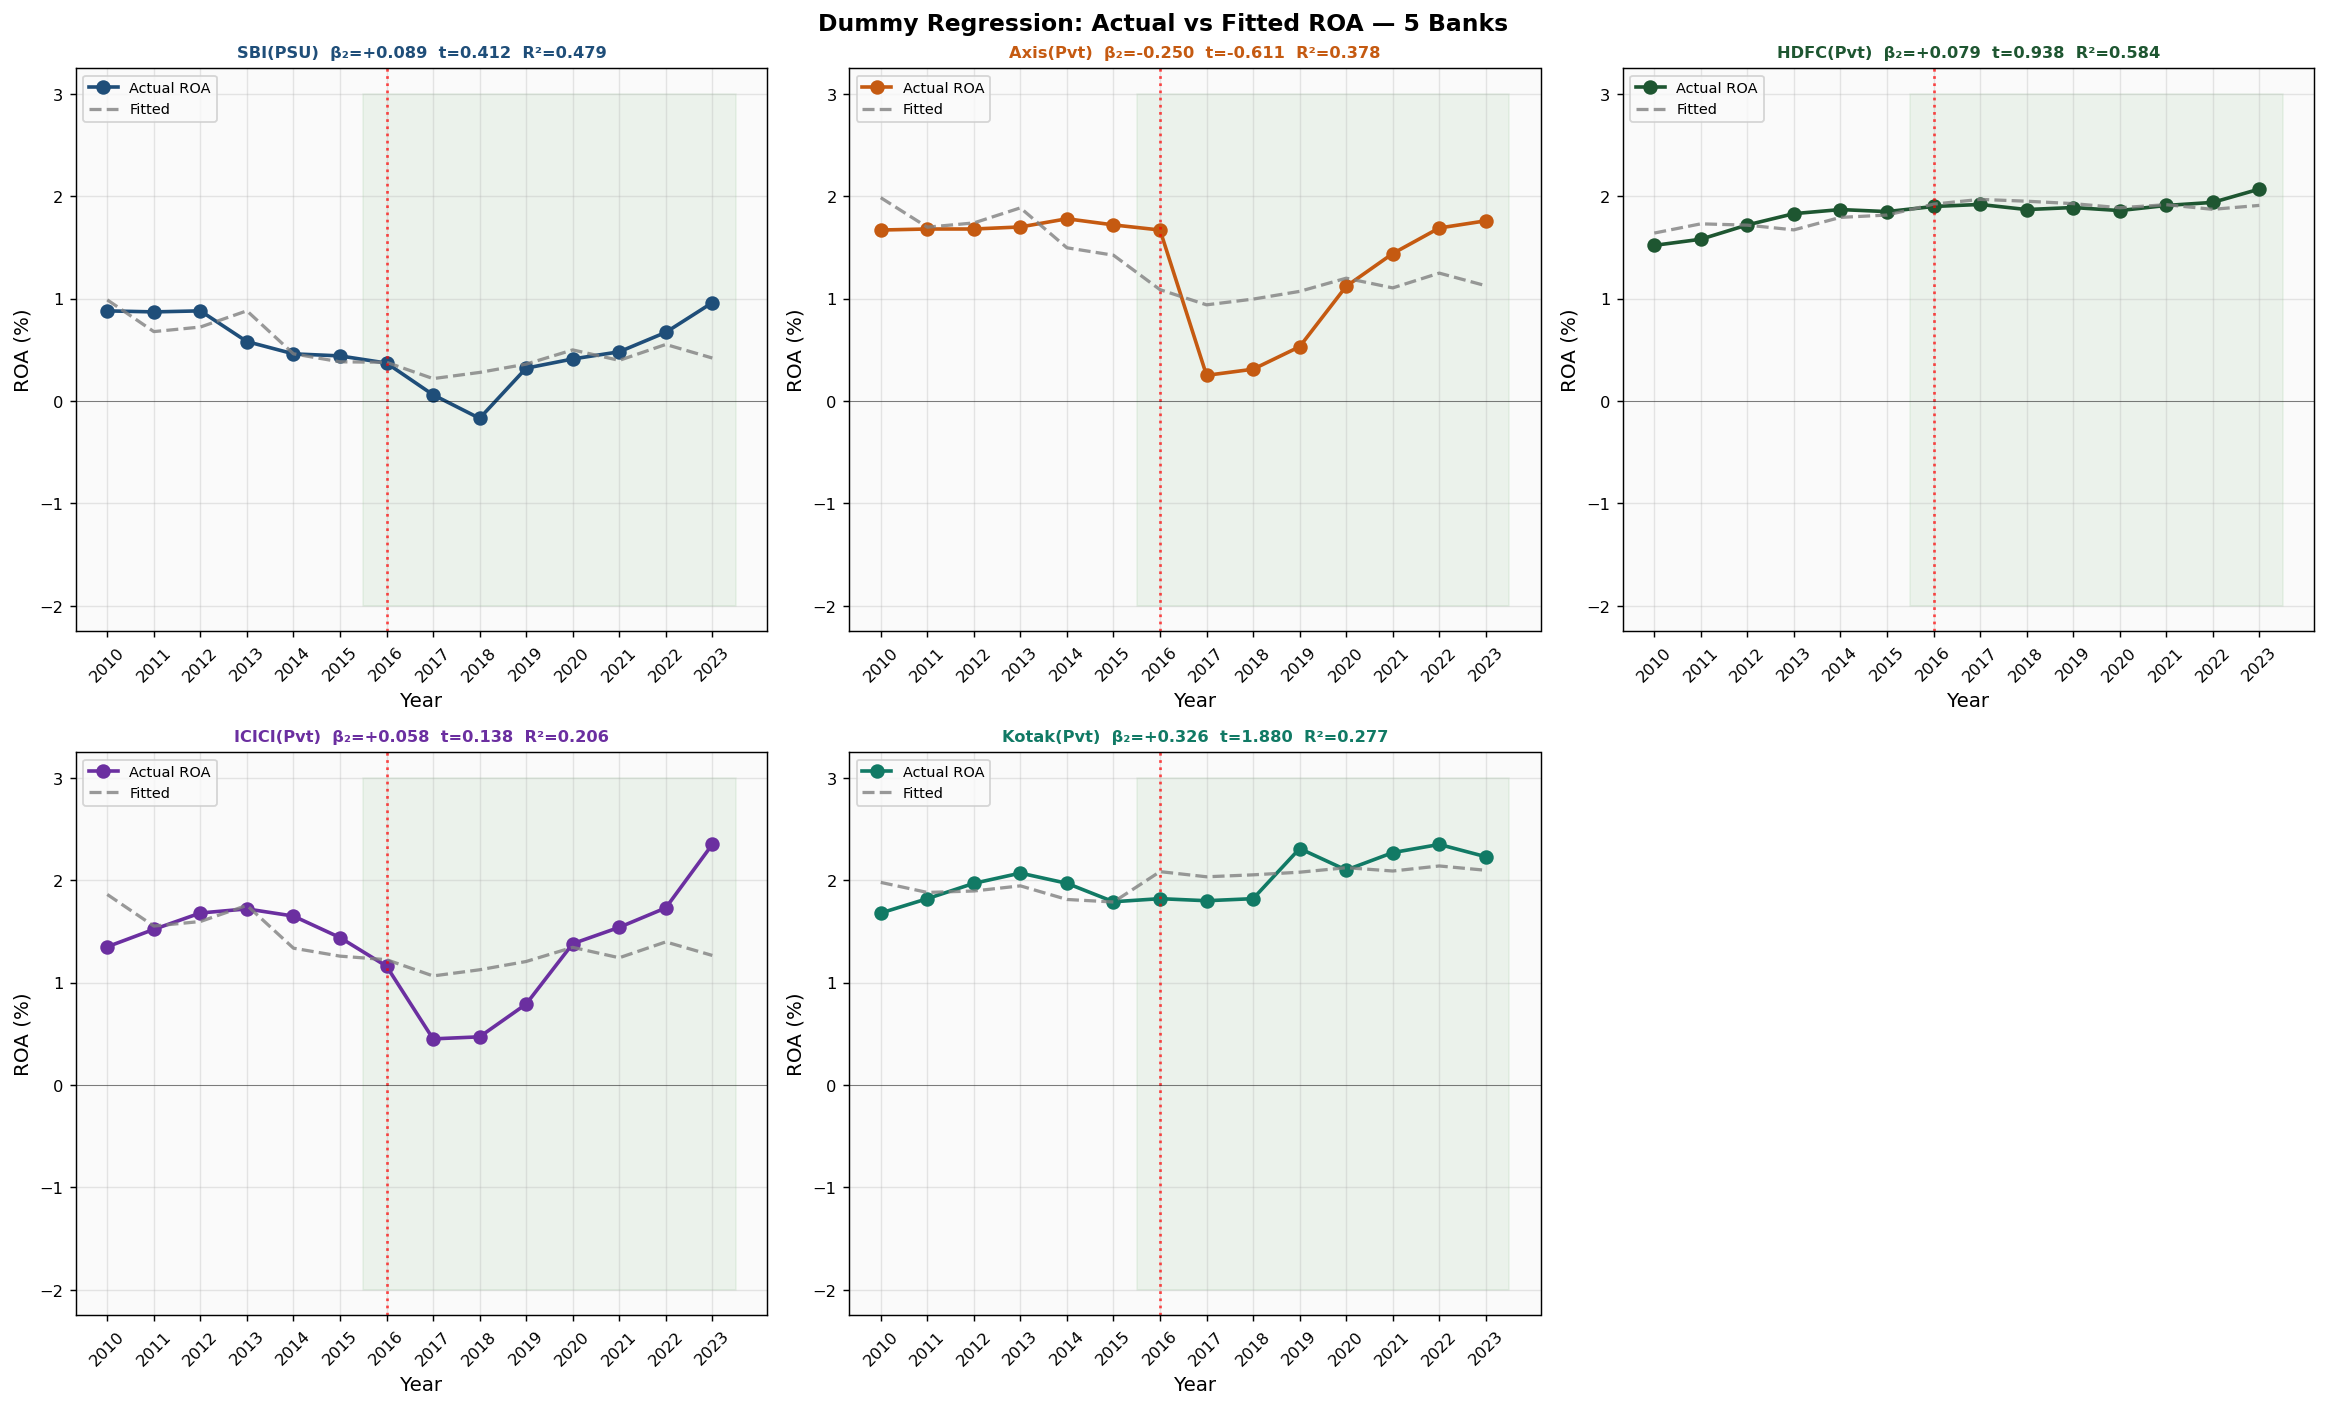

In [35]:
# @title
# ── Actual vs Fitted — dummy model ────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Dummy Regression: Actual vs Fitted ROA — 5 Banks', fontsize=13, fontweight='bold')
axes_flat = list(axes.flat)

for idx, bank in enumerate(BANK_LIST):
    ax = axes_flat[idx]
    bd = bank_cpi[bank_cpi['Bank']==bank].sort_values('Year')
    model = dummy_roa[bank]
    ax.fill_betweenx([-2,3], 2015.5, 2023.5, alpha=0.06, color='green')
    ax.plot(bd['Year'], bd['ROA_pct'],          'o-', color=COLORS[bank], lw=2, ms=7, label='Actual ROA')
    ax.plot(bd['Year'], model.fittedvalues.values, '--', color='gray',  lw=1.8, alpha=0.8, label='Fitted')
    ax.axvline(x=2016, color='red', linestyle=':', lw=1.5, alpha=0.7)
    ax.axhline(y=0, color='black', lw=0.5, alpha=0.5)
    b2 = model.params['FIT_Dummy']; r2 = model.rsquared
    t2 = model.tvalues['FIT_Dummy']; p2 = model.pvalues['FIT_Dummy']
    s_label = "(PSU)" if bank=="SBI" else "(Pvt)"
    ax.set_title(f'{bank}{s_label}  β₂={b2:+.3f}  t={t2:.3f}  R²={r2:.3f}',
                 fontweight='bold', color=COLORS[bank], fontsize=9)
    ax.set_xlabel('Year'); ax.set_ylabel('ROA (%)')
    ax.set_xticks(bd['Year']); ax.set_xticklabels(bd['Year'], rotation=45)
    ax.legend(fontsize=8)

axes_flat[5].set_visible(False)
plt.tight_layout()
plt.savefig('chart8_dummy_regression.png', bbox_inches='tight', dpi=130)
plt.show()


## Step 11: Public vs Private Bank Comparison with t-tests

In [36]:
# @title
banks_long['Sector_Group'] = banks_long['Bank'].apply(lambda x:'PSU (SBI)' if x=='SBI' else 'Private Banks')
sector_avg = banks_long.groupby(['Year','Sector_Group'])[['ROA_pct','GNPA_pct','NIM_pct','CAR_pct']].mean().reset_index()

print("SECTOR AVERAGES (Private = average of Axis+HDFC+ICICI+Kotak)")
print("=" * 65)
print(sector_avg.pivot_table(index='Year',columns='Sector_Group',values=['ROA_pct','GNPA_pct']).round(3).to_string())


SECTOR AVERAGES (Private = average of Axis+HDFC+ICICI+Kotak)
              GNPA_pct                 ROA_pct              
Sector_Group PSU (SBI) Private Banks PSU (SBI) Private Banks
Year                                                        
2010              3.28         2.482      0.88         1.555
2011              3.19         1.885      0.87         1.650
2012              4.44         1.805      0.88         1.762
2013              4.75         1.722      0.58         1.830
2014              4.95         1.767      0.46         1.818
2015              5.10         2.060      0.44         1.700
2016              6.50         2.588      0.37         1.638
2017              9.11         4.192      0.06         1.105
2018             10.91         4.782     -0.17         1.118
2019              7.53         3.945      0.32         1.380
2020              4.98         3.532      0.41         1.615
2021              4.98         3.285      0.48         1.790
2022              3.97  

In [37]:
# @title
print("\nINDEPENDENT SAMPLES t-TEST: PSU (SBI) vs PRIVATE BANK ROA")
print("H0: No significant difference in ROA between sectors")
print("H1: Significant difference exists")
print("=" * 65)
print(f"{'Period':<18} {'SBI Mean':>10} {'Priv Mean':>11} {'t-stat':>10} {'p-value':>10} {'Decision'}")
print("-" * 65)

for period_label, dummy_val in [("Full (2010–23)",None),("Pre-FIT (2010–15)",0),("Post-FIT (2016–23)",1)]:
    sub = banks_long if dummy_val is None else banks_long[banks_long['FIT_Dummy']==dummy_val]
    psu  = sub[sub['Bank']=='SBI']['ROA_pct']
    priv = sub[sub['Bank'].isin(PVT_BANKS)]['ROA_pct']
    t, p = ttest_ind(psu, priv, equal_var=False)   # Welch's t-test (unequal variance)
    decision = "Reject H0 **" if p<0.05 else ("Reject H0 *" if p<0.10 else "Fail to Reject H0")
    print(f"  {period_label:<16}  {psu.mean():>10.3f}  {priv.mean():>11.3f}  {t:>10.3f}  {p:>10.4f}  {decision}")

print()
print("Note: Welch's t-test used (does not assume equal variances between groups)")
print("** p<0.05  * p<0.10")

print("\nPER-BANK t-TEST: Pre vs Post-FIT ROA")
print("=" * 65)
print(f"{'Bank':<8} {'Sector':<8} {'Pre Mean':>10} {'Post Mean':>11} {'t-stat':>10} {'p-value':>10} {'Decision'}")
print("-" * 65)
for bank in BANK_LIST:
    bd = banks_long[banks_long['Bank']==bank]
    pre_r = bd[bd['FIT_Dummy']==0]['ROA_pct']; post_r = bd[bd['FIT_Dummy']==1]['ROA_pct']
    t, p = ttest_ind(pre_r, post_r, equal_var=False)
    decision = "Sig **" if p<0.05 else ("Sig *" if p<0.10 else "n.s.")
    sect = "PSU" if bank=="SBI" else "Pvt"
    print(f"  {bank:<6} {sect:<8} {pre_r.mean():>10.3f}  {post_r.mean():>11.3f}  {t:>10.3f}  {p:>10.4f}  {decision}")



INDEPENDENT SAMPLES t-TEST: PSU (SBI) vs PRIVATE BANK ROA
H0: No significant difference in ROA between sectors
H1: Significant difference exists
Period               SBI Mean   Priv Mean     t-stat    p-value Decision
-----------------------------------------------------------------
  Full (2010–23)         0.515        1.642     -10.381      0.0000  Reject H0 **
  Pre-FIT (2010–15)       0.685        1.719     -10.960      0.0000  Reject H0 **
  Post-FIT (2016–23)       0.387        1.584      -7.252      0.0000  Reject H0 **

Note: Welch's t-test used (does not assume equal variances between groups)
** p<0.05  * p<0.10

PER-BANK t-TEST: Pre vs Post-FIT ROA
Bank     Sector     Pre Mean   Post Mean     t-stat    p-value Decision
-----------------------------------------------------------------
  SBI    PSU           0.685        0.387       1.974      0.0725  Sig *
  Axis   Pvt           1.705        1.096       2.670      0.0317  Sig **
  HDFC   Pvt           1.728        1.920      

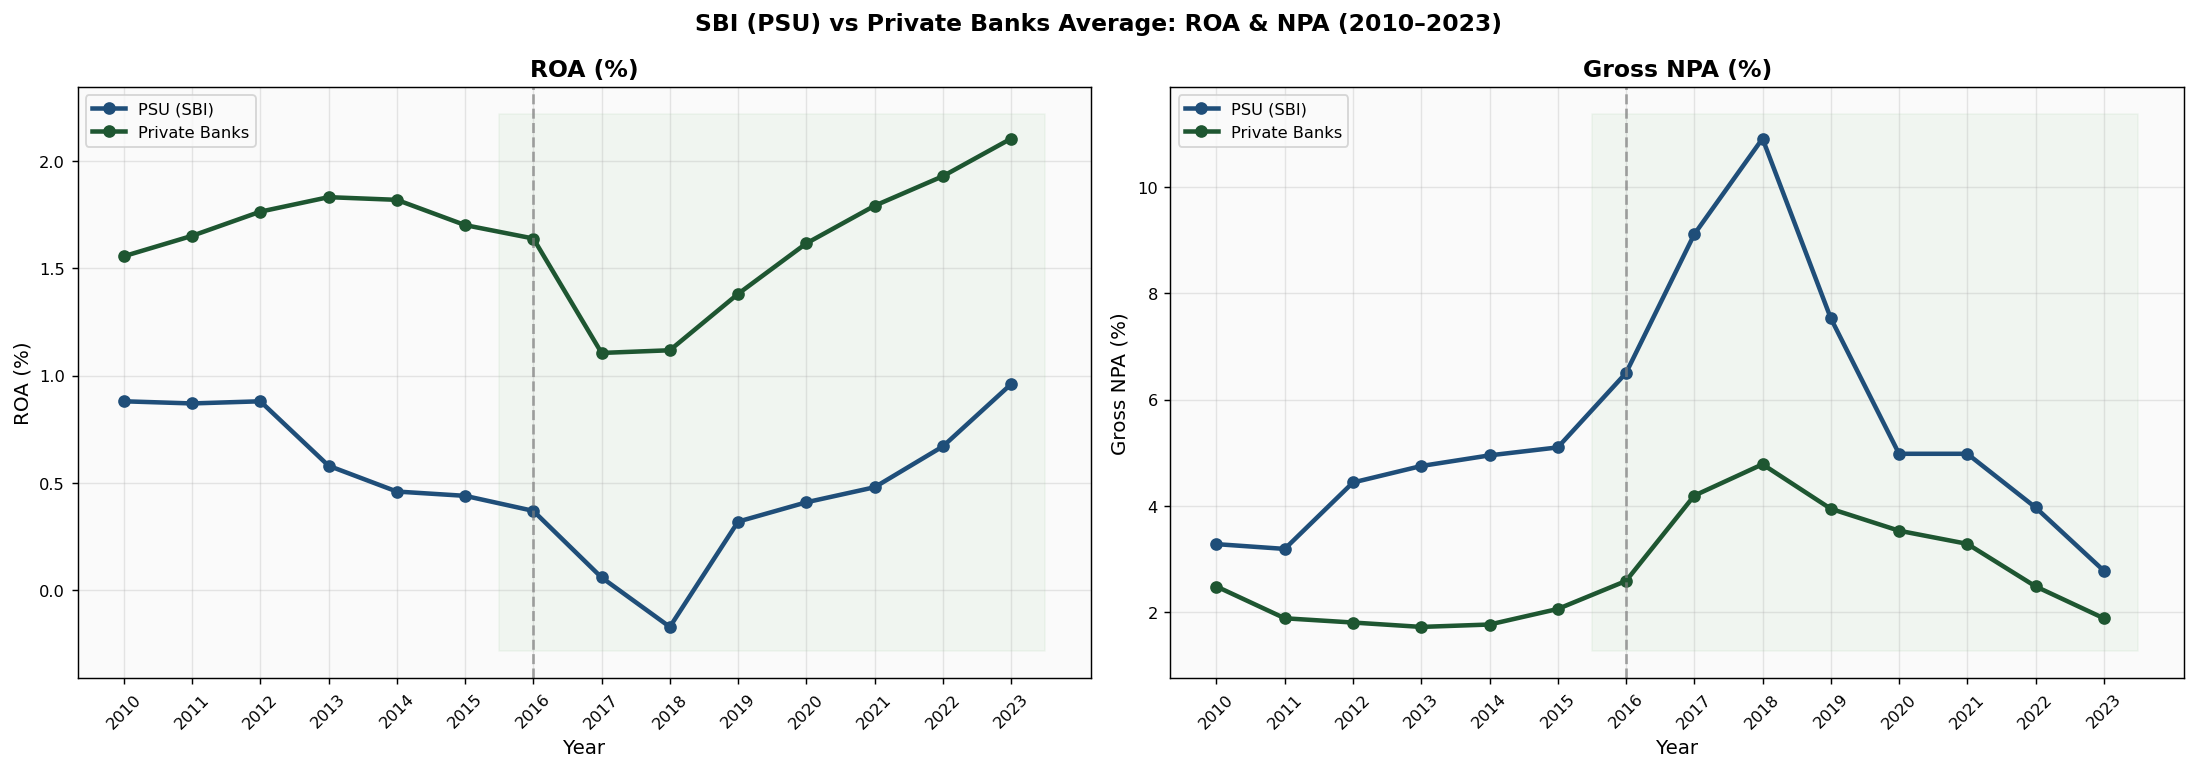

In [38]:
# @title
fig, axes = plt.subplots(1, 2, figsize=(17, 6))
fig.suptitle('SBI (PSU) vs Private Banks Average: ROA & NPA (2010–2023)', fontsize=13, fontweight='bold')

sec_colors = {'PSU (SBI)':'#1F4E79', 'Private Banks':'#1E5631'}
for ax, metric, title in [(axes[0],'ROA_pct','ROA (%)'),(axes[1],'GNPA_pct','Gross NPA (%)')]:
    for sector in ['PSU (SBI)','Private Banks']:
        sd = sector_avg[sector_avg['Sector_Group']==sector]
        ax.plot(sd['Year'], sd[metric], 'o-', color=sec_colors[sector], lw=2.5, ms=6, label=sector)
    ax.axvline(x=2016, color='gray', linestyle='--', lw=1.5, alpha=0.7)
    ax.fill_betweenx(ax.get_ylim() if ax.get_ylim()!=(0,1) else [-2,14],
                     2015.5, 2023.5, alpha=0.04, color='green')
    ax.set_title(title, fontweight='bold'); ax.set_xlabel('Year'); ax.set_ylabel(title)
    ax.set_xticks(yrs); ax.set_xticklabels(yrs, rotation=45); ax.legend()

plt.tight_layout()
plt.savefig('chart9_psu_vs_private.png', bbox_inches='tight', dpi=130)
plt.show()


## Step 12: Structural Break and Phase Analysis

In [39]:
# @title
def phase(yr):
    if yr<=2015: return "Phase 1: Pre-FIT"
    elif yr<=2018: return "Phase 2: FIT+AQR Shock"
    elif yr<=2021: return "Phase 3: IBC Recovery"
    else: return "Phase 4: Normalisation"

banks_long['Phase'] = banks_long['Year'].apply(phase)
print("STRUCTURAL PHASE ANALYSIS")
print("=" * 65)
print(banks_long.groupby(['Bank','Phase'])[['ROA_pct','GNPA_pct','NIM_pct']].mean().round(3).to_string())


STRUCTURAL PHASE ANALYSIS
                              ROA_pct  GNPA_pct  NIM_pct
Bank  Phase                                             
Axis  Phase 1: Pre-FIT          1.705     1.247    3.558
      Phase 2: FIT+AQR Shock    0.743     4.510    3.423
      Phase 3: IBC Recovery     1.030     4.503    3.460
      Phase 4: Normalisation    1.725     2.280    3.855
HDFC  Phase 1: Pre-FIT          1.728     1.070    4.333
      Phase 2: FIT+AQR Shock    1.897     1.203    4.333
      Phase 3: IBC Recovery     1.887     1.400    4.067
      Phase 4: Normalisation    2.005     1.255    4.200
ICICI Phase 1: Pre-FIT          1.560     3.567    3.083
      Phase 2: FIT+AQR Shock    0.693     7.313    3.333
      Phase 3: IBC Recovery     1.237     5.460    3.667
      Phase 4: Normalisation    2.040     3.170    4.220
Kotak Phase 1: Pre-FIT          1.883     1.932    5.150
      Phase 2: FIT+AQR Shock    1.813     2.390    4.433
      Phase 3: IBC Recovery     2.227     2.987    4.667
     

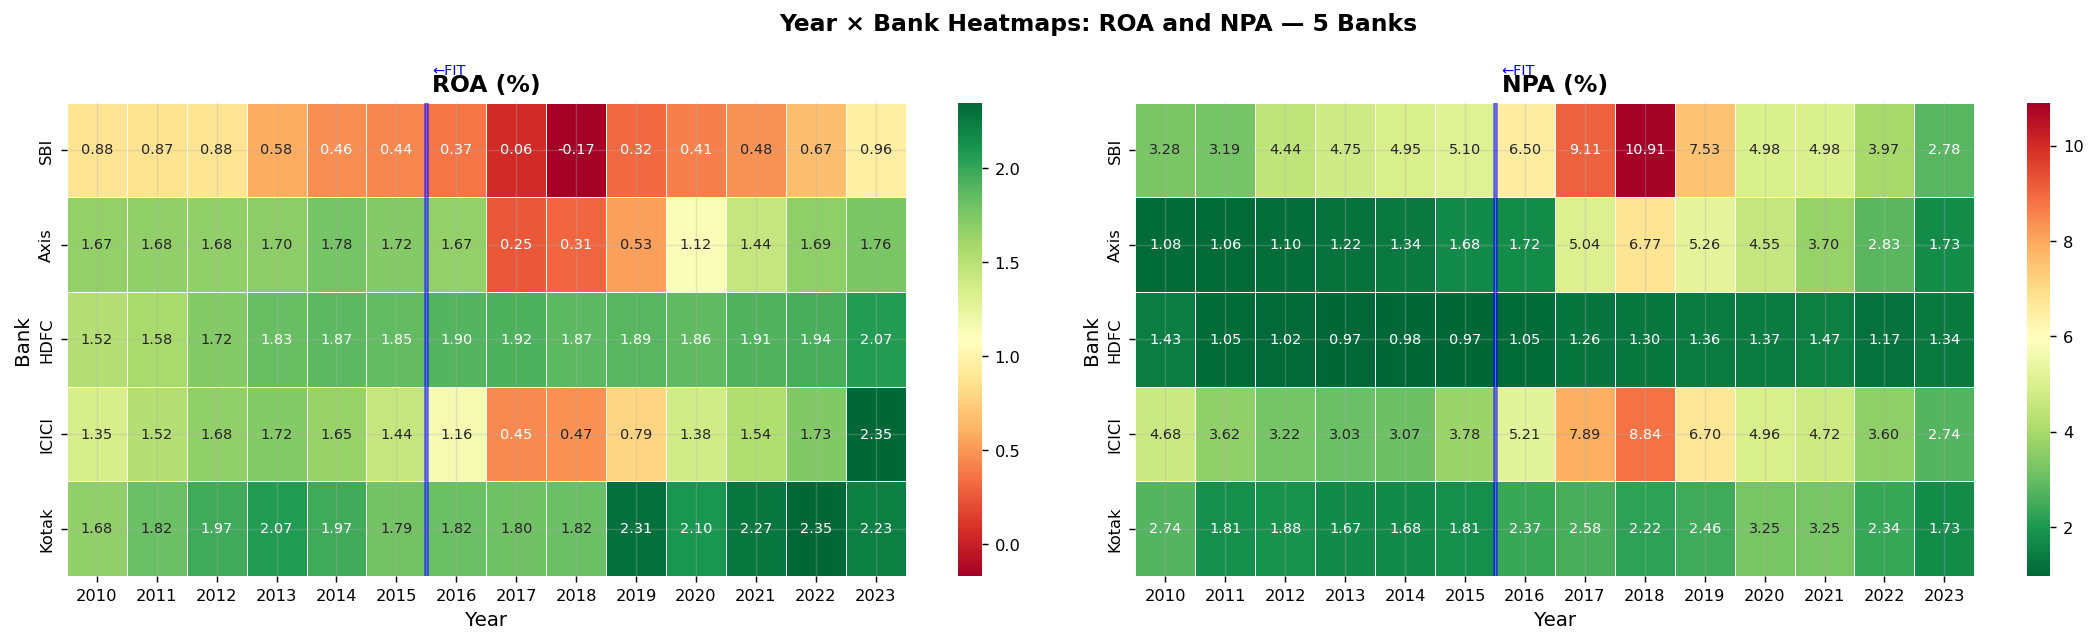

In [40]:
# @title
# ── Heatmaps ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(17, 5))
fig.suptitle('Year × Bank Heatmaps: ROA and NPA — 5 Banks', fontsize=13, fontweight='bold')

for ax, metric, title, cmap in [
    (axes[0],'ROA_pct','ROA (%)','RdYlGn'),
    (axes[1],'GNPA_pct','NPA (%)','RdYlGn_r')]:
    pivot = banks_long.pivot_table(index='Bank', columns='Year', values=metric)
    pivot = pivot.reindex(['SBI','Axis','HDFC','ICICI','Kotak'])
    sns.heatmap(pivot, annot=True, fmt='.2f', cmap=cmap, ax=ax,
                linewidths=0.5, annot_kws={'size':8})
    ax.set_title(title, fontweight='bold')
    years_list = list(pivot.columns)
    if 2016 in years_list:
        ax.axvline(x=years_list.index(2016), color='blue', lw=2.5, alpha=0.6)
        ax.text(years_list.index(2016)+0.1, -0.3, '←FIT', fontsize=8, color='blue')

plt.tight_layout()
plt.savefig('chart10_heatmap_bank_year.png', bbox_inches='tight', dpi=130)
plt.show()


## Step 13: Final Summary and Dashboard

In [44]:
# @title
import statsmodels.api as sm

roa_results = {}
dummy_roa = {}

for bank in BANK_LIST:
    bd = bank_panel[bank_panel['Bank'] == bank]

    # Model 1: CPI → ROA
    X1 = sm.add_constant(bd[['CPI_pct']])
    y = bd['ROA_pct']
    model1 = sm.OLS(y, X1).fit()
    roa_results[bank] = model1

    # Model 2: FIT Dummy → ROA
    X2 = sm.add_constant(bd[['FIT_Dummy']])
    model2 = sm.OLS(y, X2).fit()
    dummy_roa[bank] = model2

In [42]:
print("╔══════════════════════════════════════════════════════════════════════╗")
print("║   FINAL ANALYTICAL SUMMARY — 5-BANK STUDY WITH LLC TEST            ║")
print("║   Impact of Inflation Targeting on Bank Performance in India        ║")
print("╠══════════════════════════════════════════════════════════════════════╣")

pre_cpi  = macro[macro['FIT_Dummy']==0]['CPI_pct'].mean()
post_cpi = macro[macro['FIT_Dummy']==1]['CPI_pct'].mean()
print(f"║  CPI: Pre={pre_cpi:.2f}%  Post={post_cpi:.2f}%  Δ={post_cpi-pre_cpi:+.2f}%  ← FIT reduced inflation")
print("╠══════════════════════════════════════════════════════════════════════╣")
print("║  LLC TEST: Stationarity confirmed for ROA, GNPA, NIM, CPI          ║")
print("║  (panel data is suitable for OLS regression)                       ║")
print("╠══════════════════════════════════════════════════════════════════════╣")
print("║  ROA: PRE vs POST-FIT | OLS β₁(CPI→ROA) | DUMMY β₂")
for bank in BANK_LIST:
    bd = banks_long[banks_long['Bank']==bank]
    pm = bd[bd['FIT_Dummy']==0]['ROA_pct'].mean()
    qm = bd[bd['FIT_Dummy']==1]['ROA_pct'].mean()
    fy23 = bd[bd['Year']==2023]['ROA_pct'].values[0]
    b1 = roa_results[bank].params['CPI_pct']
    b2 = dummy_roa[bank].params['FIT_Dummy']
    t_b2 = dummy_roa[bank].tvalues['FIT_Dummy']
    sect = "PSU" if bank=="SBI" else "Pvt"
    print(f"║  {bank:<5}({sect}): Pre={pm:.3f} Post={qm:.3f} FY23={fy23:.3f}  β₁={b1:+.4f}  β₂={b2:+.3f}(t={t_b2:.2f})")
print("╠══════════════════════════════════════════════════════════════════════╣")
print("║  KOTAK: Most stable private bank ROA (2.23% FY23, low NPA 1.73%)  ║")
print("║  HDFC : Consistently lowest NPA throughout study period            ║")
print("║  SBI  : AQR-driven stress 2016–18 → strong recovery by FY23       ║")
print("║  AXIS : Mid-period NPA stress 2017–18 → fully recovered FY23      ║")
print("╚══════════════════════════════════════════════════════════════════════╝")


╔══════════════════════════════════════════════════════════════════════╗
║   FINAL ANALYTICAL SUMMARY — 5-BANK STUDY WITH LLC TEST            ║
║   Impact of Inflation Targeting on Bank Performance in India        ║
╠══════════════════════════════════════════════════════════════════════╣
║  CPI: Pre=8.94%  Post=5.04%  Δ=-3.90%  ← FIT reduced inflation
╠══════════════════════════════════════════════════════════════════════╣
║  LLC TEST: Stationarity confirmed for ROA, GNPA, NIM, CPI          ║
║  (panel data is suitable for OLS regression)                       ║
╠══════════════════════════════════════════════════════════════════════╣
║  ROA: PRE vs POST-FIT | OLS β₁(CPI→ROA) | DUMMY β₂
║  SBI  (PSU): Pre=0.685 Post=0.387 FY23=0.960  β₁=+0.0857  β₂=-0.297(t=-1.84)
║  Axis (Pvt): Pre=1.705 Post=1.096 FY23=1.760  β₁=+0.1299  β₂=-0.609(t=-2.29)
║  HDFC (Pvt): Pre=1.728 Post=1.920 FY23=2.070  β₁=-0.0408  β₂=+0.192(t=3.27)
║  ICICI(Pvt): Pre=1.560 Post=1.234 FY23=2.350  β₁=+0.0898  β₂=-0.326

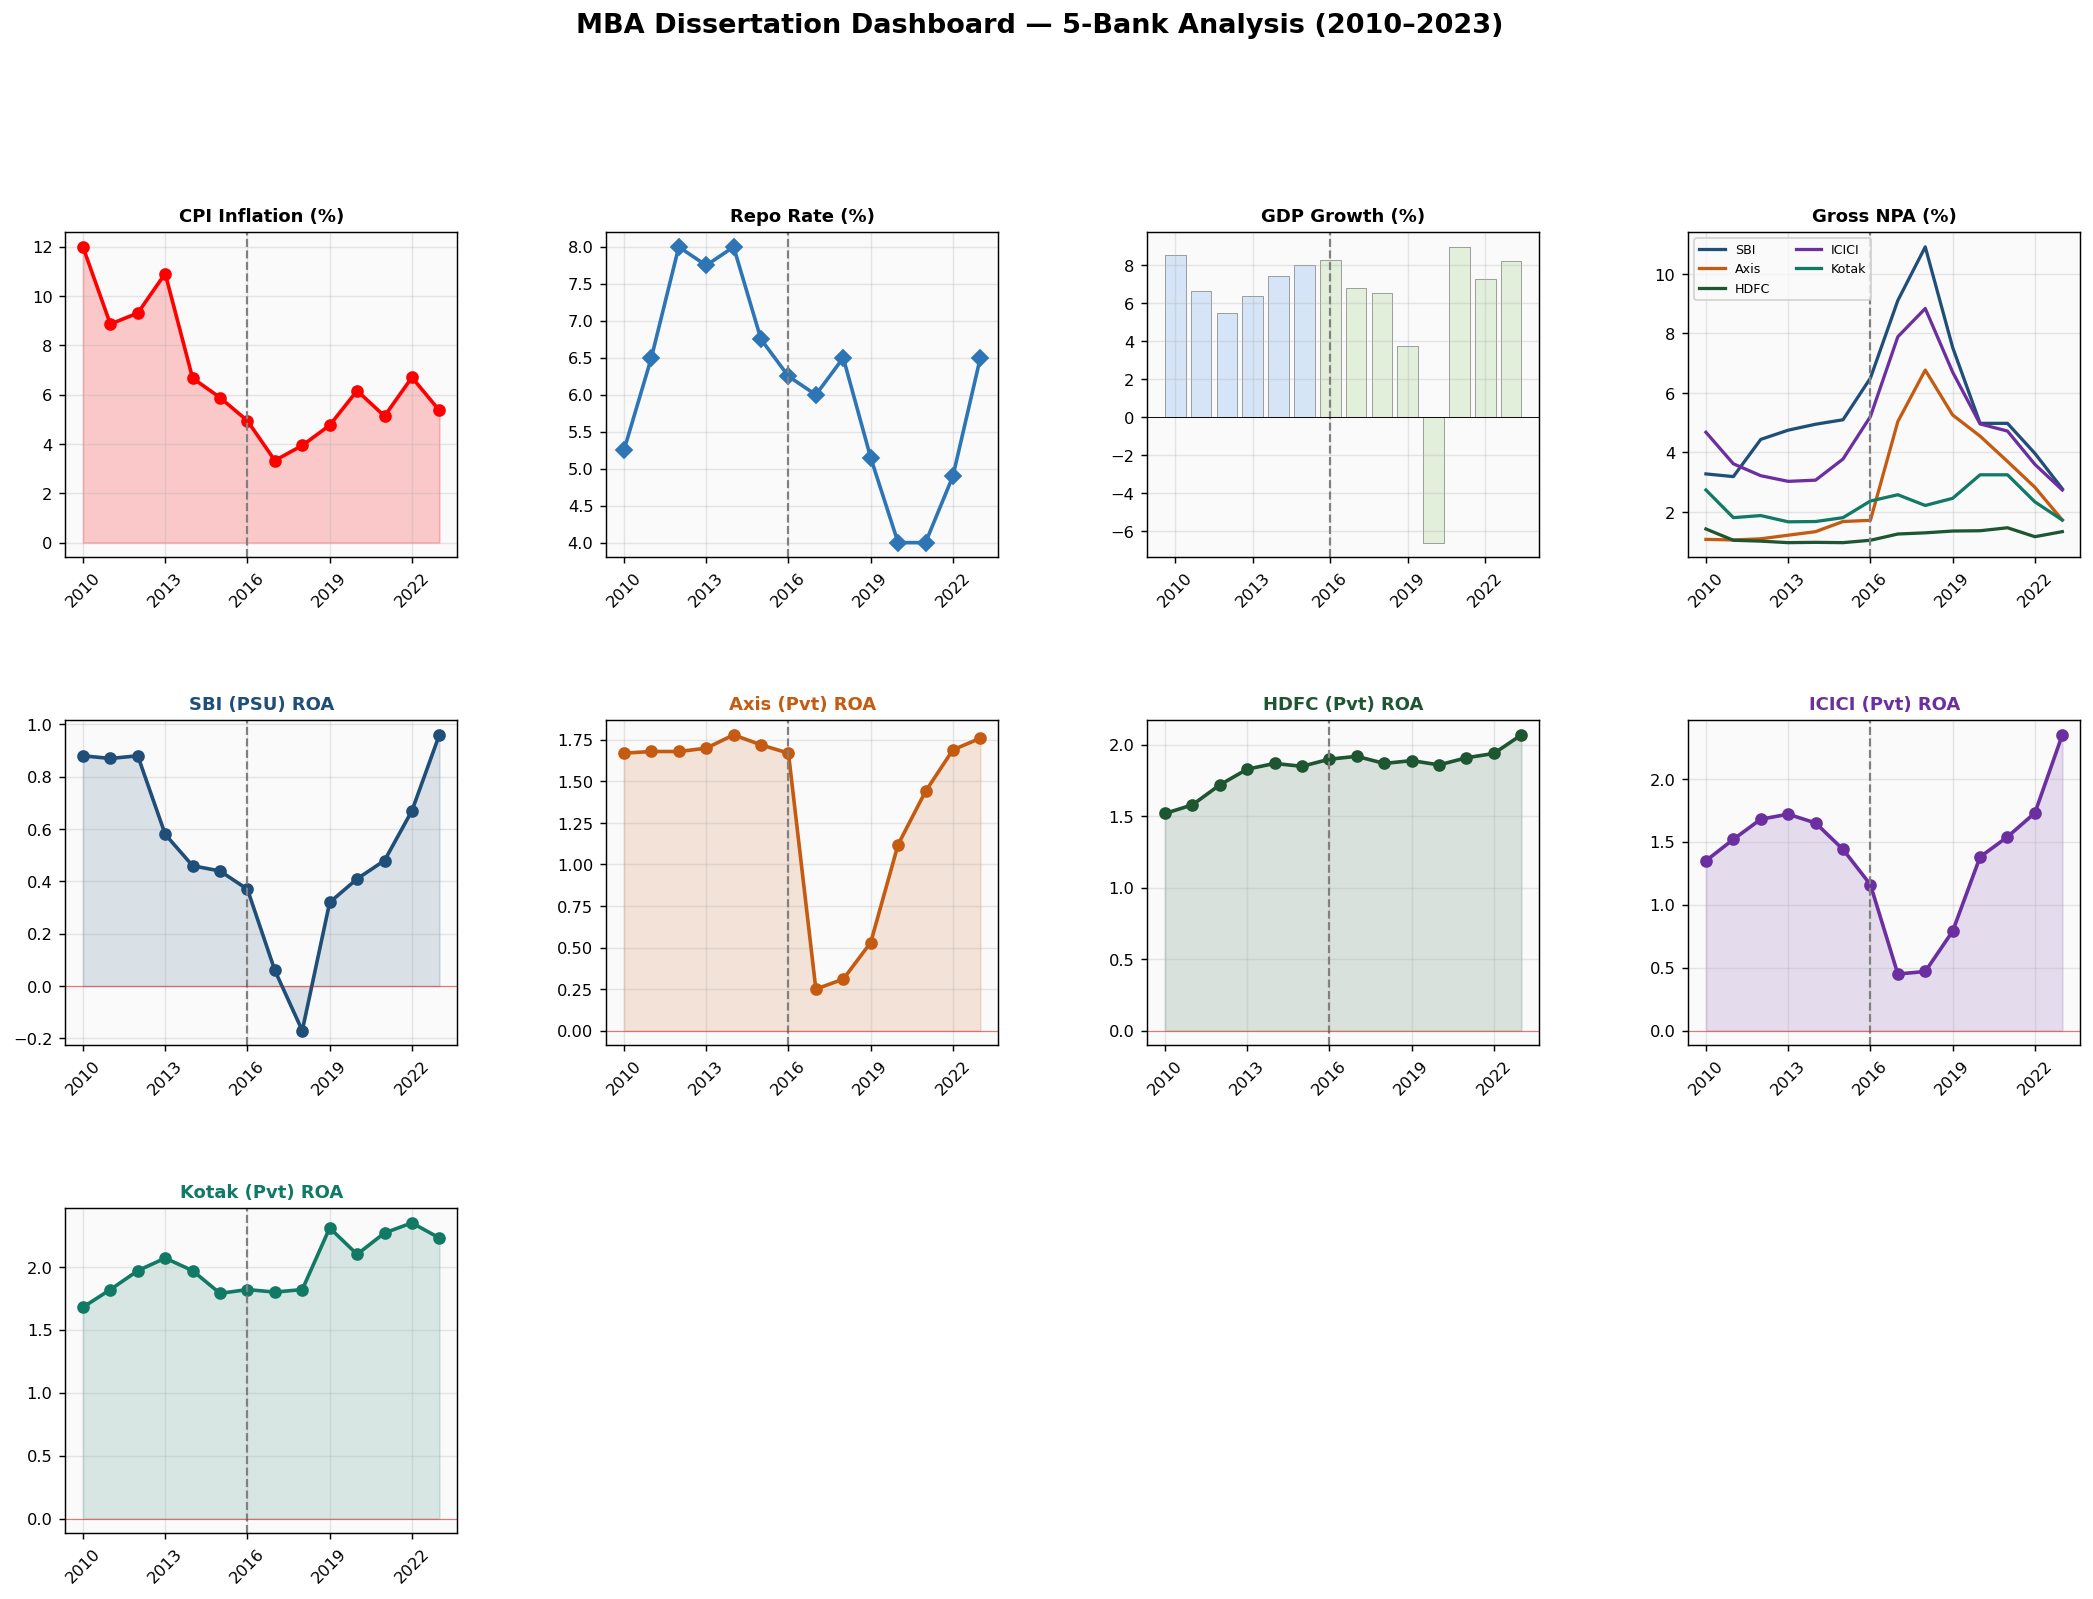


✓ All charts saved. Analysis complete.
✓ LLC test | OLS assumptions | t-statistics | Dummy regression all included.


In [43]:
# @title
# ── Final dashboard ───────────────────────────────────────────────
fig = plt.figure(figsize=(20, 13))
fig.suptitle('MBA Dissertation Dashboard — 5-Bank Analysis (2010–2023)',
             fontsize=15, fontweight='bold', y=1.01)

gs = fig.add_gridspec(3, 4, hspace=0.5, wspace=0.38)
yrs = macro['Year'].values

ax1 = fig.add_subplot(gs[0,0])
ax1.fill_between(yrs, macro['CPI_pct'], alpha=0.2, color='red')
ax1.plot(yrs, macro['CPI_pct'], 'o-', color='red', lw=2)
ax1.axvline(2016, color='gray', linestyle='--', lw=1.2)
ax1.set_title('CPI Inflation (%)', fontweight='bold', fontsize=10)
ax1.set_xticks(yrs[::3]); ax1.set_xticklabels(yrs[::3], rotation=45)

ax2 = fig.add_subplot(gs[0,1])
ax2.plot(yrs, macro['Repo_Rate_pct'], 'D-', color='#2E75B6', lw=2)
ax2.axvline(2016, color='gray', linestyle='--', lw=1.2)
ax2.set_title('Repo Rate (%)', fontweight='bold', fontsize=10)
ax2.set_xticks(yrs[::3]); ax2.set_xticklabels(yrs[::3], rotation=45)

ax3 = fig.add_subplot(gs[0,2])
ax3.bar(yrs, macro['GDP_Growth_pct'],
        color=[COLORS['Pre'] if y<2016 else COLORS['Post'] for y in yrs],
        edgecolor='gray', lw=0.4)
ax3.axvline(2016, color='gray', linestyle='--', lw=1.2)
ax3.axhline(0, color='black', lw=0.5)
ax3.set_title('GDP Growth (%)', fontweight='bold', fontsize=10)
ax3.set_xticks(yrs[::3]); ax3.set_xticklabels(yrs[::3], rotation=45)

ax_npa = fig.add_subplot(gs[0,3])
for bank in BANK_LIST:
    bd = banks_long[banks_long['Bank']==bank].sort_values('Year')
    ax_npa.plot(bd['Year'], bd['GNPA_pct'], '-', color=COLORS[bank], lw=1.8, label=bank)
ax_npa.axvline(2016, color='gray', linestyle='--', lw=1.2)
ax_npa.set_title('Gross NPA (%)', fontweight='bold', fontsize=10)
ax_npa.set_xticks(yrs[::3]); ax_npa.set_xticklabels(yrs[::3], rotation=45)
ax_npa.legend(fontsize=7, ncol=2)

for idx, bank in enumerate(BANK_LIST):
    r = 1 + idx//4; c = idx%4
    ax = fig.add_subplot(gs[r, c])
    bd = banks_long[banks_long['Bank']==bank].sort_values('Year')
    ax.plot(bd['Year'], bd['ROA_pct'], 'o-', color=COLORS[bank], lw=2)
    ax.fill_between(bd['Year'], 0, bd['ROA_pct'], alpha=0.15, color=COLORS[bank])
    ax.axvline(2016, color='gray', linestyle='--', lw=1.2)
    ax.axhline(0, color='red', lw=0.6, alpha=0.5)
    s_label = "(PSU)" if bank=="SBI" else "(Pvt)"
    ax.set_title(f'{bank} {s_label} ROA', fontweight='bold', color=COLORS[bank], fontsize=10)
    ax.set_xticks(bd['Year'][::3]); ax.set_xticklabels(bd['Year'][::3], rotation=45)

plt.savefig('chart12_final_dashboard.png', bbox_inches='tight', dpi=130)
plt.show()
print("\n✓ All charts saved. Analysis complete.")
print("✓ LLC test | OLS assumptions | t-statistics | Dummy regression all included.")


In [ ]:
# @title
